# OBJECTIVE
This notebook performs exploratory data analysis (EDA) and statistical testing on the Ludo dataset.

## Goals
- Load and validate the latest generated dataset from the 4-token-per-player Ludo simulation.
- Assess data quality (missing values, duplicates, and outliers) across all 12 columns.
- Distinguish structural missingness (e.g., no legal move, `Token_Moved = 0`) from problematic missingness.
- Apply a cleaning rule for analysis: if missingness does not affect core analysis columns, remove missing rows for complete-case modeling tables.
- Explore variable distributions and relationships using visualizations for token-state features (`Token_Moved`, `Position_Before`, `Position_After`, `Tokens_Home`, `Tokens_Active`, `Tokens_Finished`, `Captured_Opponent`).
- Evaluate statistical assumptions (normality) globally and within player groups.
- Apply non-parametric tests (Kruskal-Wallis and Mann-Whitney U) where appropriate.
- Highlight group concentration zones (IQR, median, and peak) in significant test plots for clearer interpretation.
- Produce interpretable outputs to guide feature engineering and model development.

### Cell explanation
**Purpose:** Import required libraries and load the latest generated Ludo dataset.

**Input:** Candidate file paths to the newest cleaned/raw CSV outputs.

**Output:** A validated DataFrame `df` preview (`df.head()`) with shape and source path.

**Interpretation:** Confirms the newest dataset is found, has the expected 12-column schema, and is ready for EDA/statistical testing.
- `Game_ID`, `Turn`, `Player`, `Dice_Roll` — game identifiers and dice outcome.
- `Token_Moved` — which token (1–4) was moved; 0 means no legal move was available.
- `Position_Before`, `Position_After` — token board positions before and after the move (0 = home, 1–56 = board, 57 = finished; NaN when no move).
- `Tokens_Home`, `Tokens_Active`, `Tokens_Finished` — per-player token-state counts after the move.
- `Captured_Opponent` — 1 if an opponent token was sent back to home, 0 otherwise.
- `Is_Winner` — 1 for all moves belonging to the game winner, 0 otherwise.


In [1]:
# Importing libraries and loading the latest ludo dataset
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

EXPECTED_COLUMNS = [
    "Game_ID", "Turn", "Player", "Dice_Roll", "Token_Moved",
    "Position_Before", "Position_After", "Tokens_Home",
    "Tokens_Active", "Tokens_Finished", "Captured_Opponent", "Is_Winner",
]

# Prefer newest generated cleaned/raw outputs and support notebook/root execution
candidate_paths = [
    Path("data file/Raw_Data/ludo_dataset_cleaned.csv"),
    Path("data file/Raw_Data/ludo_dataset.csv"),
    Path("../data file/Raw_Data/ludo_dataset_cleaned.csv"),
    Path("../data file/Raw_Data/ludo_dataset.csv"),
    Path("data file/Clean_Data/ludo_dataset_cleaned.csv"),
    Path("../data file/Clean_Data/ludo_dataset_cleaned.csv"),
]

dataset_path = next((p for p in candidate_paths if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Could not find a Ludo dataset CSV in expected locations.")

df = pd.read_csv(dataset_path)

missing_cols = [c for c in EXPECTED_COLUMNS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Dataset schema mismatch. Missing columns: {missing_cols}")

df = df[EXPECTED_COLUMNS].copy()

print(f"Loaded dataset from: {dataset_path}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded dataset from: ../data file/Raw_Data/ludo_dataset_cleaned.csv
Shape: 11104 rows x 12 columns


,Game_ID,Turn,Player,Dice_Roll,Token_Moved,Position_Before,Position_After,Tokens_Home,Tokens_Active,Tokens_Finished,Captured_Opponent,Is_Winner
0,0,1,Red,6,1,0.0,1.0,3,1,0,0,0
1,0,2,Red,1,1,1.0,2.0,3,1,0,0,0
2,0,3,Green,6,3,0.0,1.0,3,1,0,0,0
3,0,4,Green,2,3,1.0,3.0,3,1,0,0,0
4,0,5,Yellow,2,0,NaN,NaN,4,0,0,0,0


### Cell explanation
**Purpose:** Generate descriptive statistics for all columns.

**Input:** Full DataFrame `df`.

**Output:** Summary table with counts, central tendency, spread, and category frequency info.

**Interpretation:** Provides a quick overview of data structure and variable behavior.

In [2]:
df.describe(include='all')

,Game_ID,Turn,Player,Dice_Roll,Token_Moved,Position_Before,Position_After,Tokens_Home,Tokens_Active,Tokens_Finished,Captured_Opponent,Is_Winner
count,11104.000000,11104.000000,11104,11104.000000,11104.000000,8556.000000,8556.000000,11104.000000,11104.000000,11104.000000,11104.000000,11104.000000
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Yellow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,12.412374,221.648955,NaN,3.529449,1.931646,27.702665,30.532258,2.226135,0.746938,1.026927,0.020353,0.258015
std,7.779826,136.878921,NaN,1.719823,1.436679,19.192122,18.745258,1.062539,0.434786,0.989950,0.141211,0.437562
min,0.000000,1.000000,NaN,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,107.000000,NaN,2.000000,1.000000,10.000000,13.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,13.000000,214.000000,NaN,4.000000,2.000000,27.000000,30.000000,2.000000,1.000000,1.000000,0.000000,0.000000
75%,19.000000,323.000000,NaN,5.000000,3.000000,46.000000,50.000000,3.000000,1.000000,2.000000,0.000000,1.000000


### Cell explanation
**Purpose:** Check missing values per column.

**Input:** DataFrame `df`.

**Output:** Count of null entries for each variable.

**Interpretation:** Identifies completeness issues that may require cleaning or imputation.

In [3]:
df.isnull().sum()

Game_ID                 0
Turn                    0
Player                  0
Dice_Roll               0
Token_Moved             0
Position_Before      2548
Position_After       2548
Tokens_Home             0
Tokens_Active           0
Tokens_Finished         0
Captured_Opponent       0
Is_Winner               0
dtype: int64

### Cell explanation
**Purpose:** Detect duplicated rows in the dataset.

**Input:** DataFrame `df`.

**Output:** Total number of duplicate records.

**Interpretation:** Helps assess whether repeated observations could bias analysis.

In [4]:
df.duplicated().sum()

np.int64(0)

### Cell explanation
**Purpose:** Visualize numeric-variable outliers using boxplots.

**Input:** Numeric subset `df_num`.

**Output:** A grid of boxplots (one per numeric column).

**Interpretation:** Highlights potential outliers and spread differences across variables.

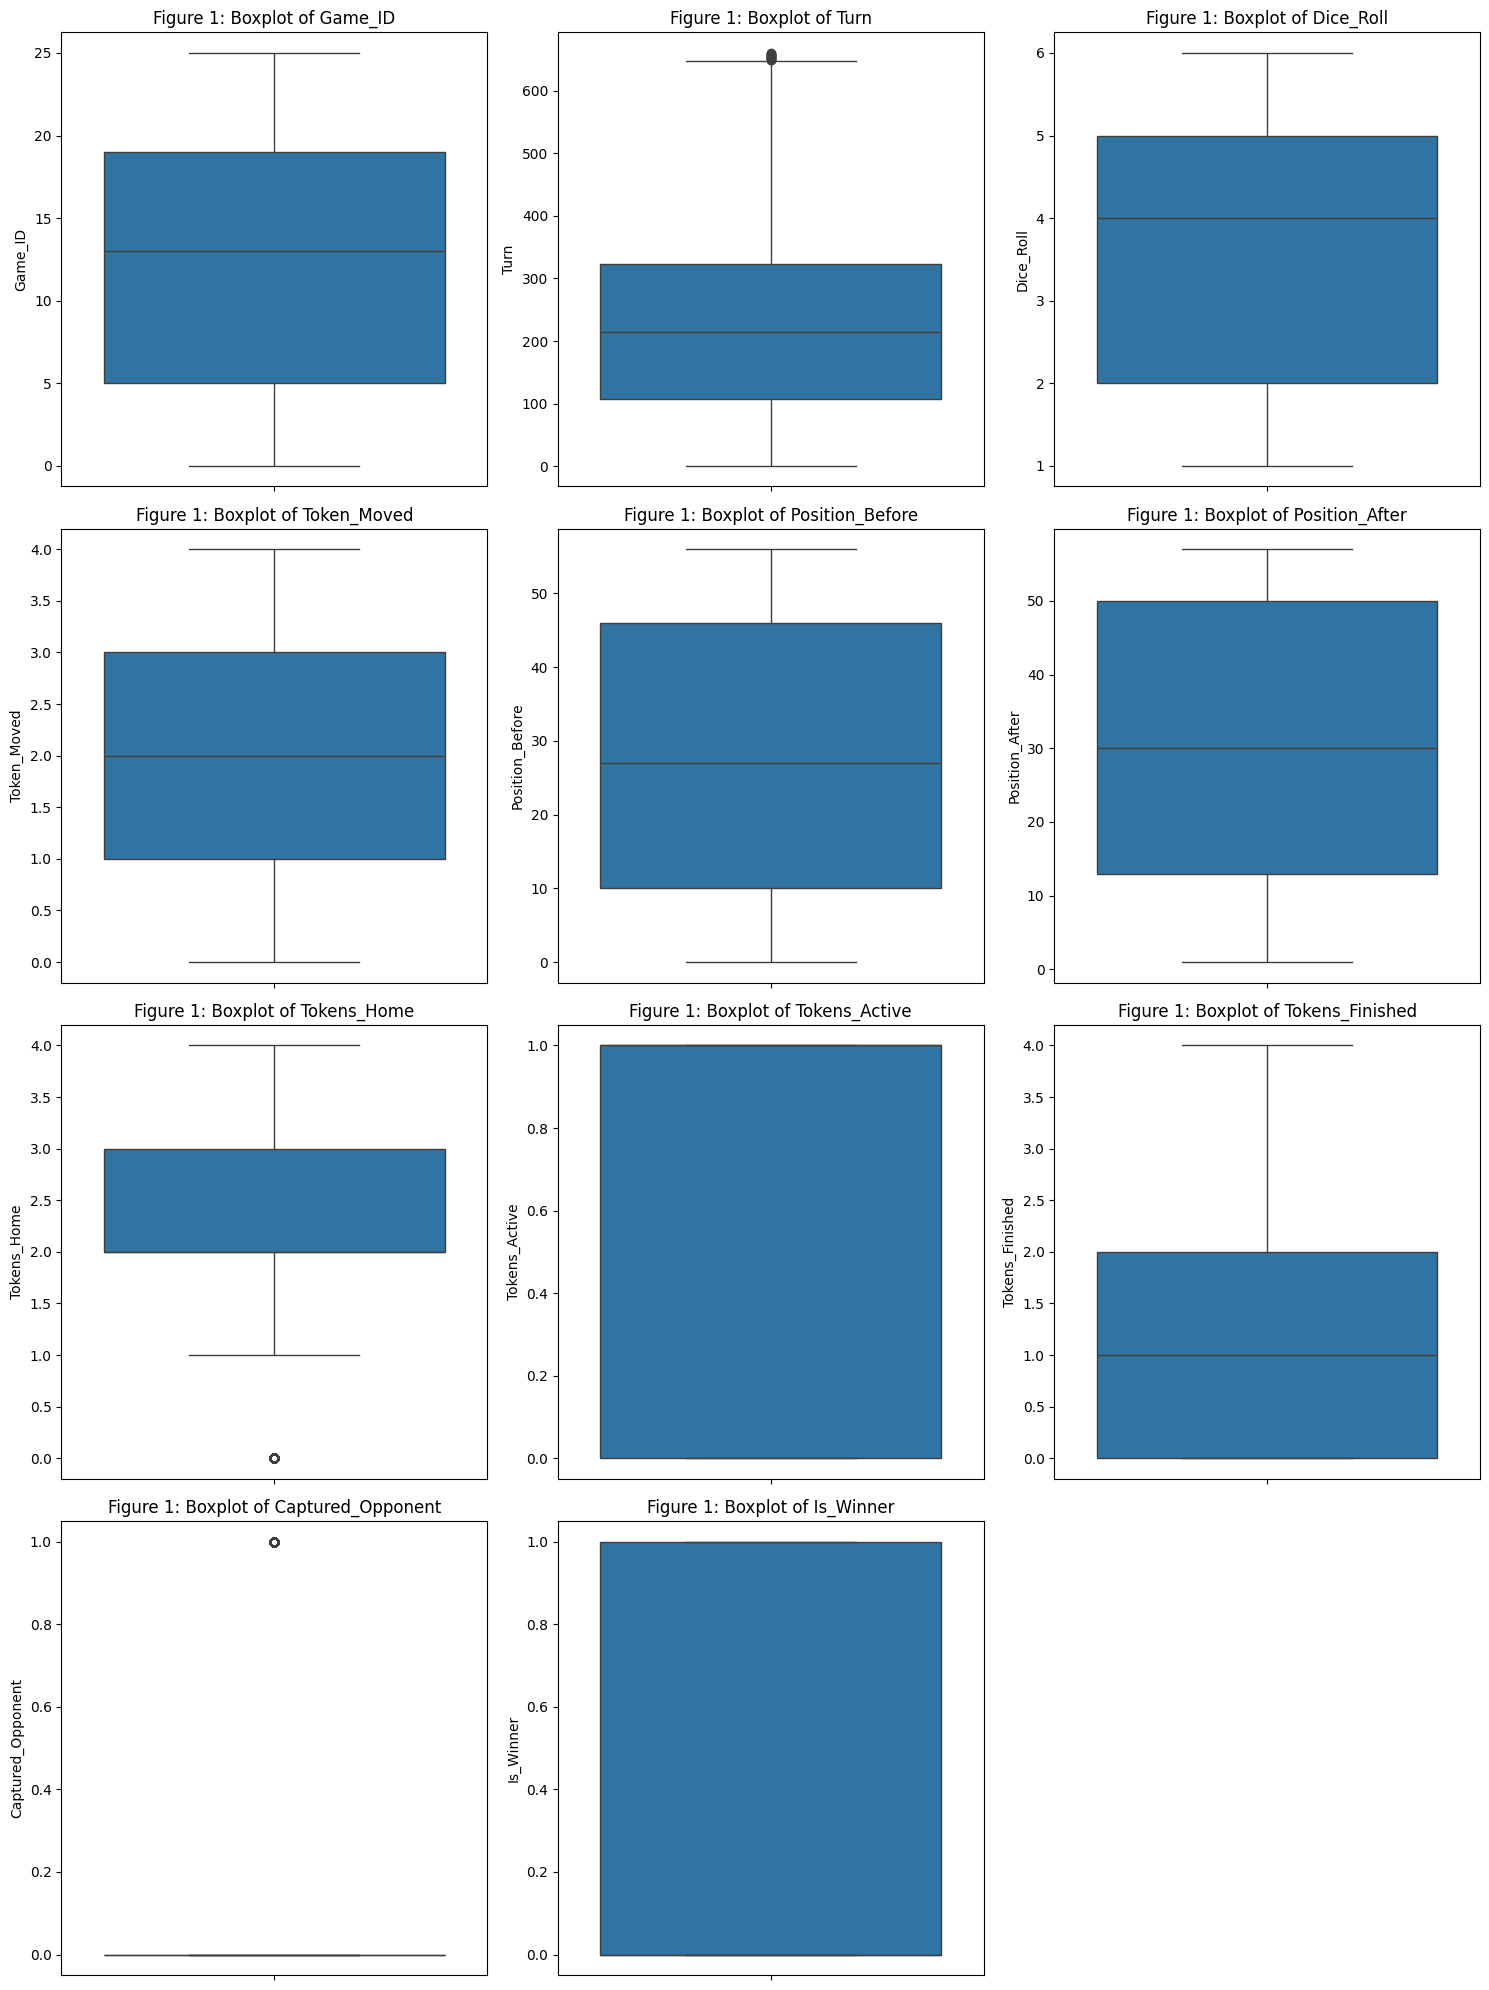

In [5]:
# Checking for outliers in the numeric variables using boxplots
import math

df_num = df.select_dtypes(include=[np.number])
n_cols = 3
n_rows = math.ceil(len(df_num.columns) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    sns.boxplot(y=df_num[col], ax=axes[i])
    axes[i].set_title(f'Figure 1: Boxplot of {col}')

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### Cell explanation
**Purpose:** Save the cleaned working dataset.

**Input:** Current DataFrame `df` and `dataset_path`.

**Output:** `ludo_dataset_cleaned.csv` written to disk.

**Interpretation:** Persists the cleaned data for reuse in later analysis steps.

In [6]:
# Save the cleaned dataset to a new CSV file
cleaned_dataset_path = dataset_path.parent / "ludo_dataset_cleaned.csv"
df.to_csv(cleaned_dataset_path, index=False)


### Cell explanation
**Purpose:** Explore numeric distributions with histograms and KDE curves.

**Input:** Numeric subset `df_num`.

**Output:** Distribution plots for each numeric variable.

**Interpretation:** Reveals shape, skewness, and modality for continuous features.

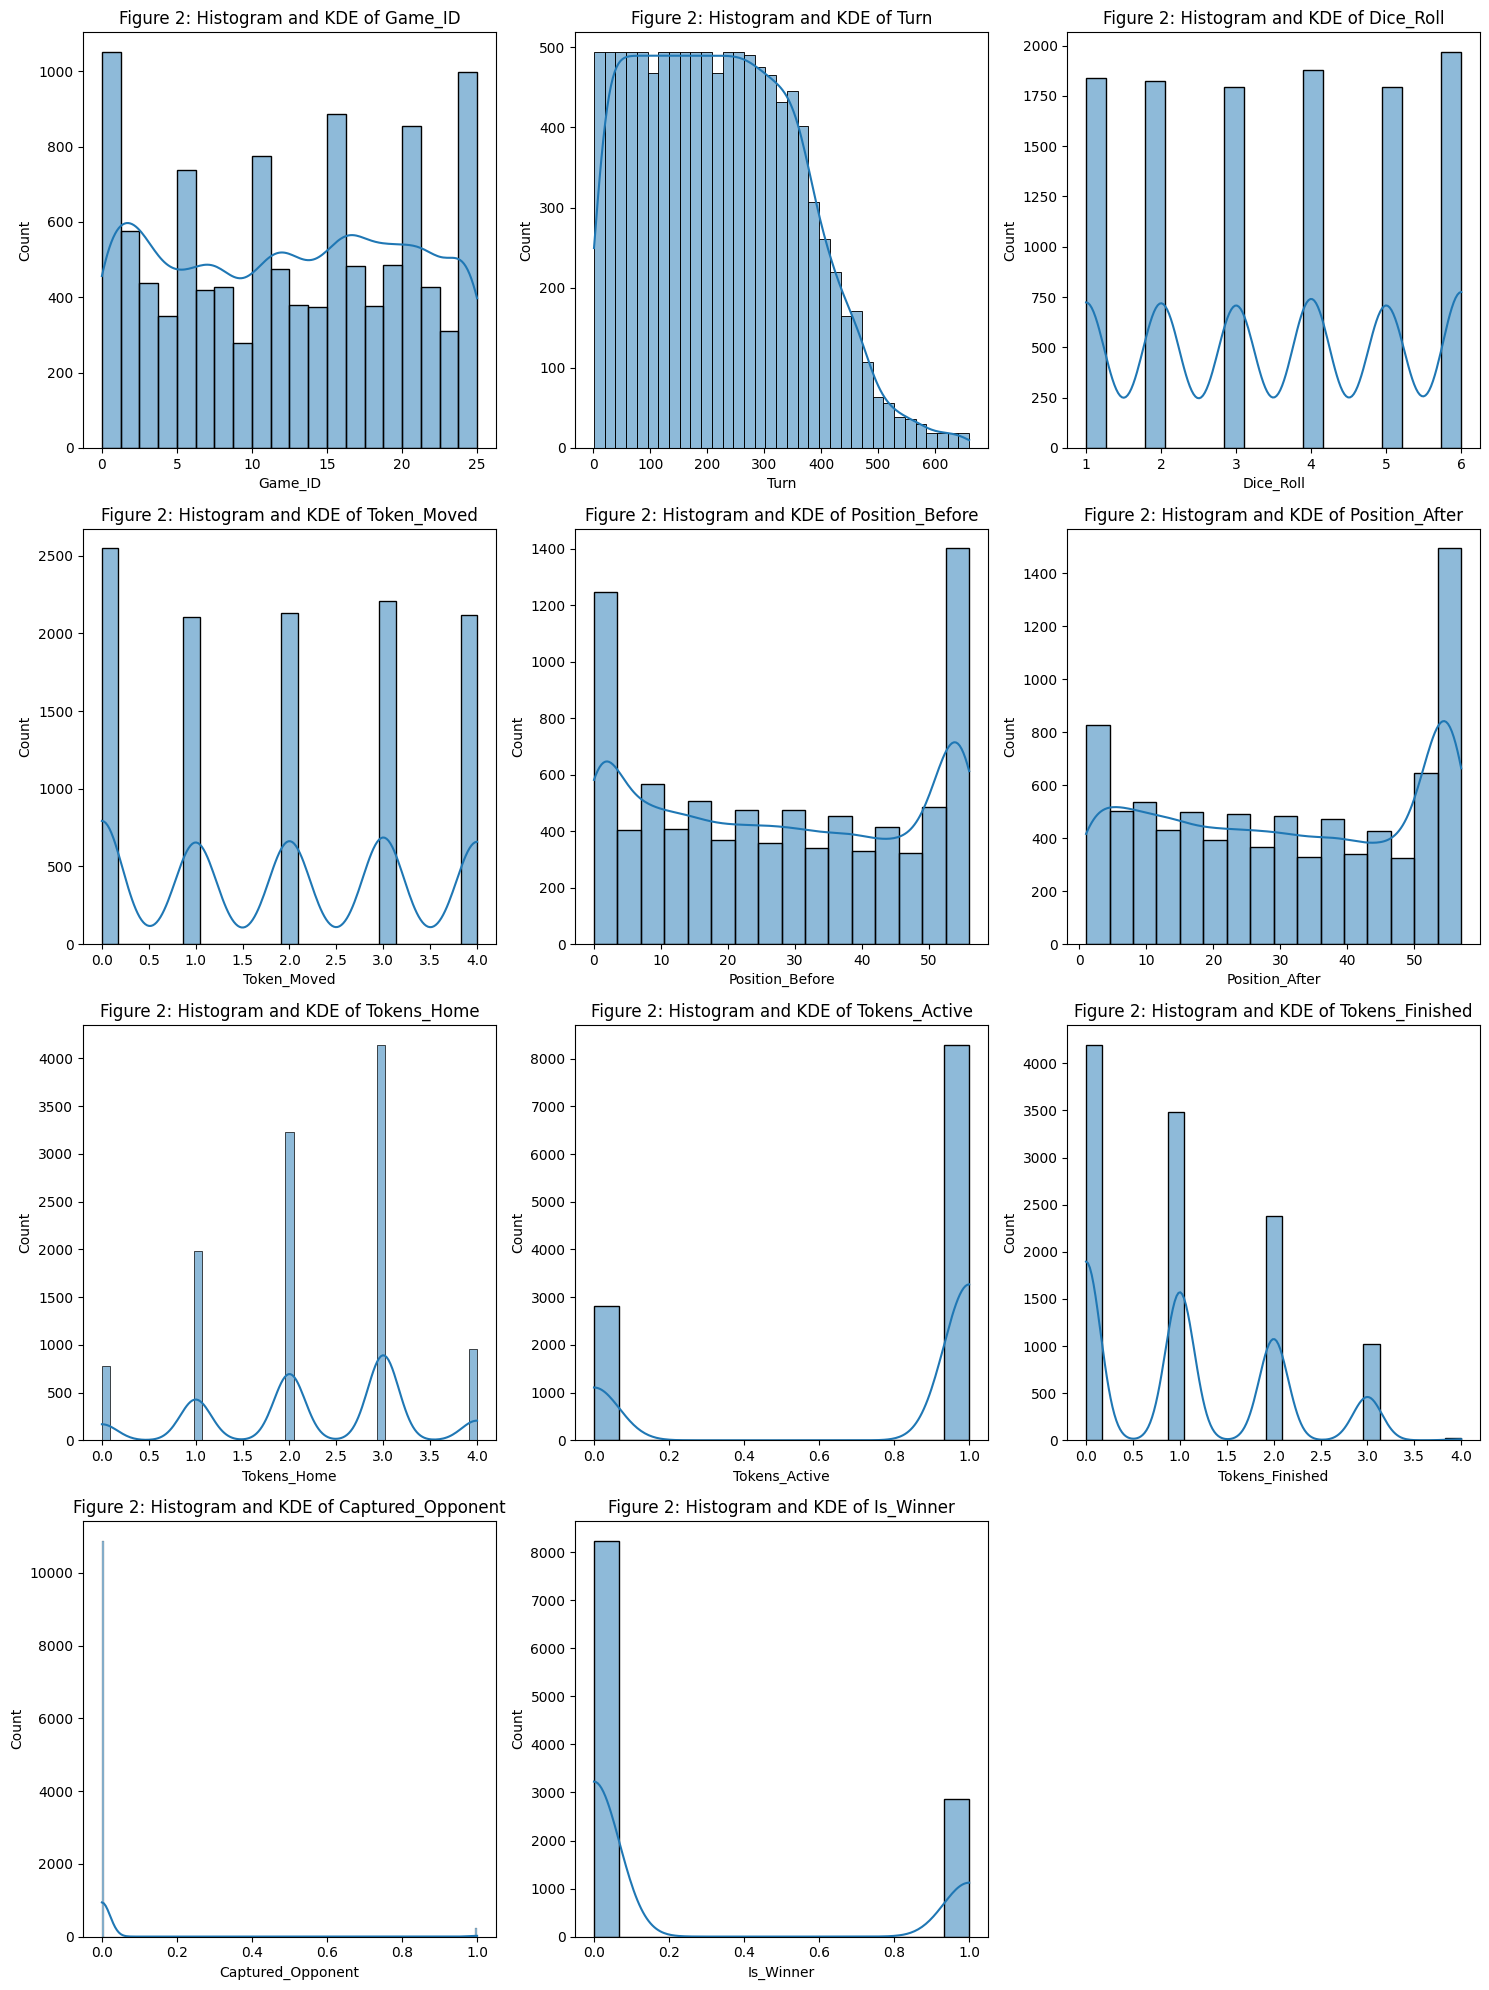

In [7]:
# Visualize the numeric variables using histograms and KDE plots
import math

df_num = df.select_dtypes(include=[np.number])
n_cols = 3
n_rows = math.ceil(len(df_num.columns) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    sns.histplot(df_num[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Figure 2: Histogram and KDE of {col}')

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### Cell explanation
**Purpose:** Examine pairwise relationships between numeric variables.

**Input:** Numeric subset `df_num`.

**Output:** Pairplot with regression lines.

**Interpretation:** Shows potential associations, trends, and collinearity patterns.

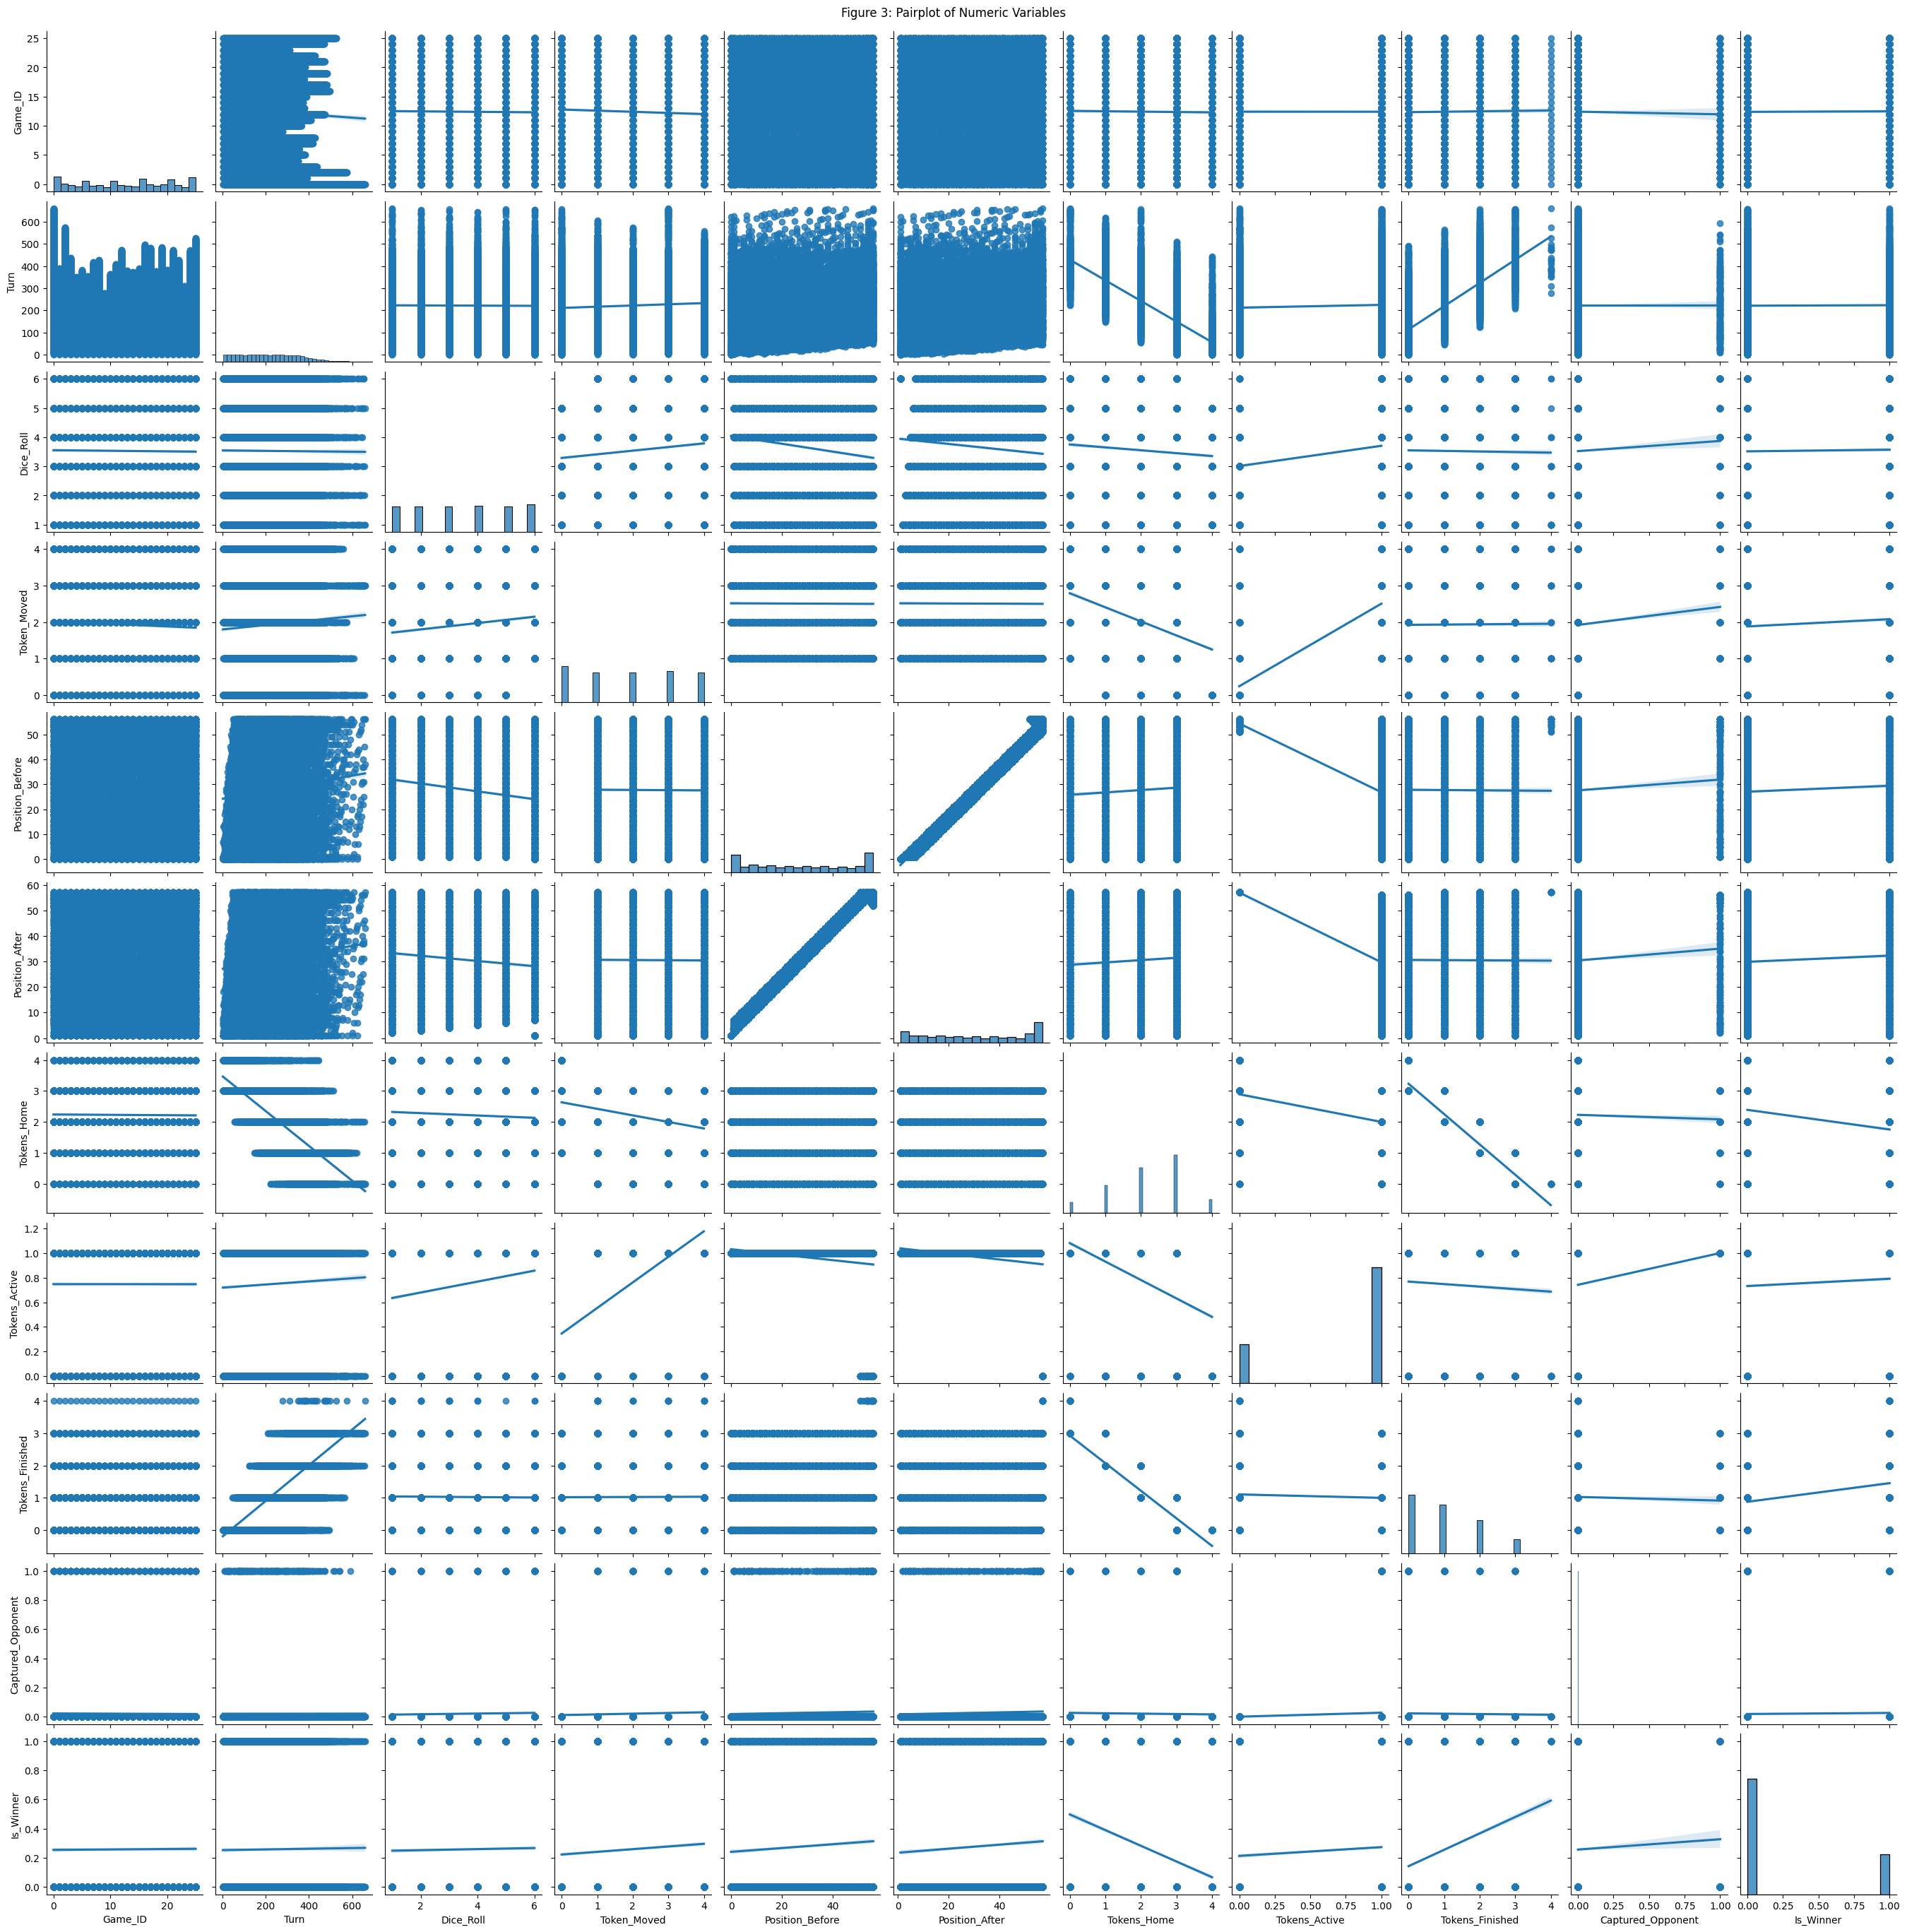

In [8]:
# Visualization of the relationships between numeric variables using pairplot with a regression line
sns.pairplot(df_num, kind='reg')
plt.suptitle('Figure 3: Pairplot of Numeric Variables', y=1)
plt.show()

### Cell explanation
**Purpose:** Visualize categorical-variable frequencies.

**Input:** Categorical subset `df_cat`.

**Output:** Countplot(s) for category levels.

**Interpretation:** Indicates class balance and dominant categories.

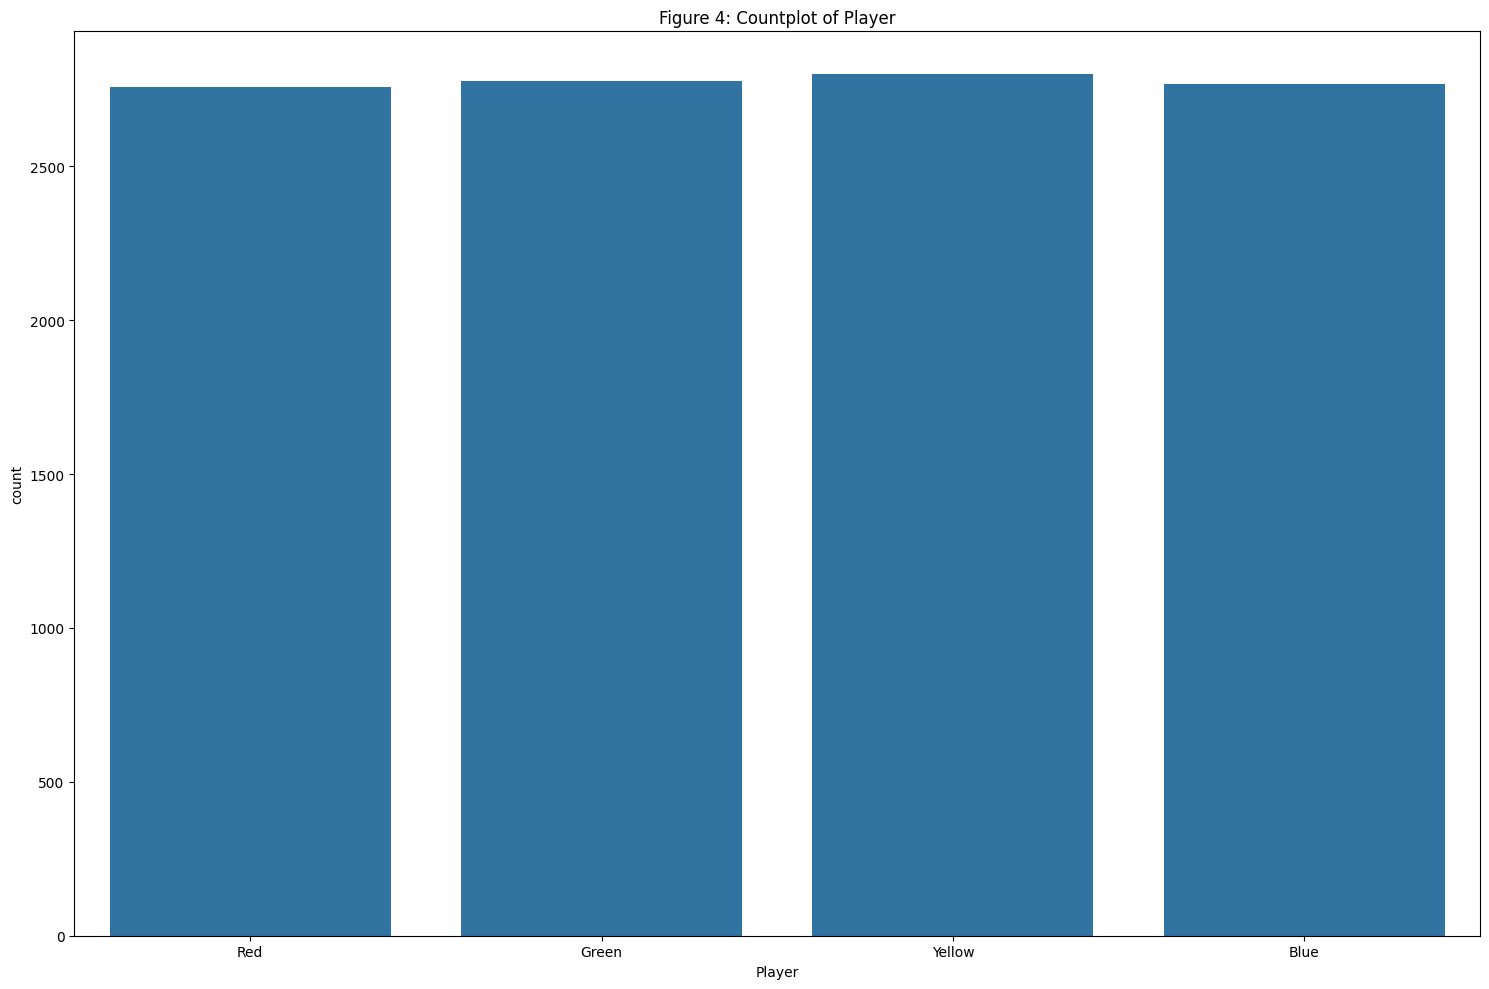

In [9]:
# Distribution of categorical variables using countplots removing unnecessary axes

df_cat=df.select_dtypes(include=['object'])
figure= plt.subplots(nrows=1, ncols=1, figsize=(15, 10))
for i, col in enumerate(df_cat.columns):
    sns.countplot(x=df_cat[col], ax=plt.gca())
    plt.title(f'Figure 4: Countplot of {col}')
plt.tight_layout()
plt.show()

### Cell explanation
**Purpose:** Compare numeric distributions across categorical groups.

**Input:** `df_cat`, `df_num`, and original DataFrame `df`.

**Output:** Boxplots of each numeric variable grouped by each categorical variable.

**Interpretation:** Helps identify group-level differences and potential effects.

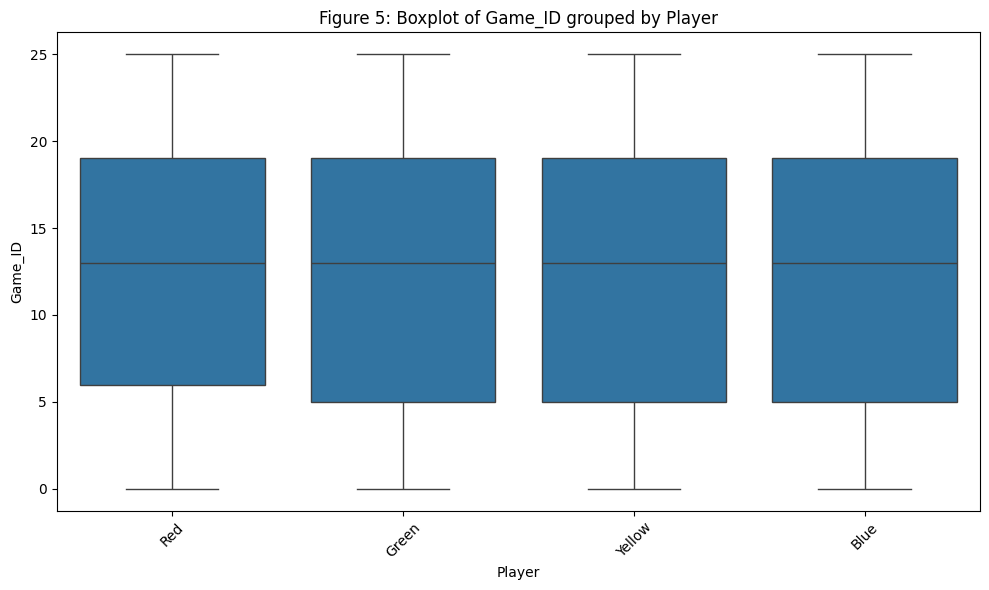

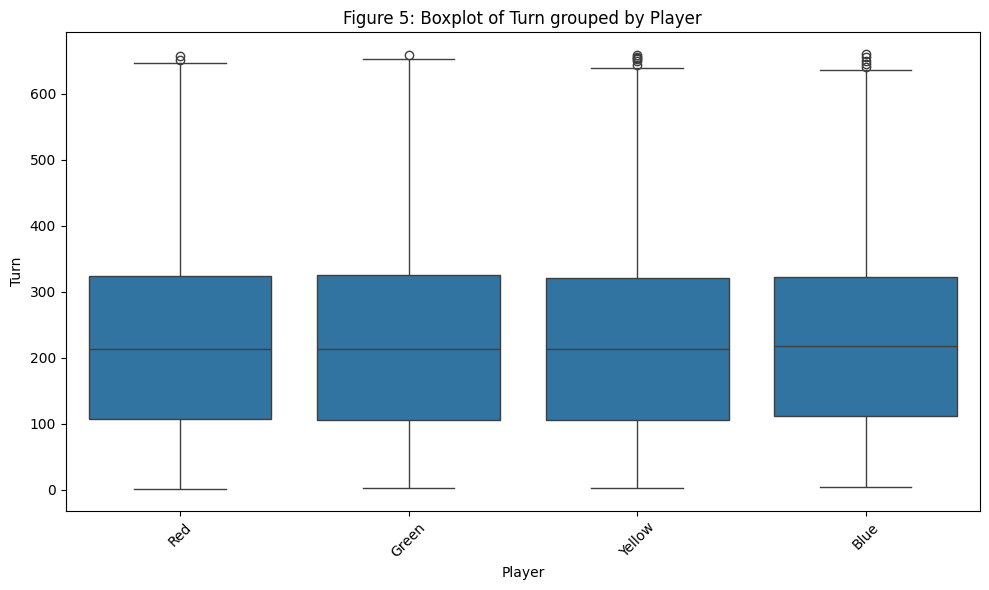

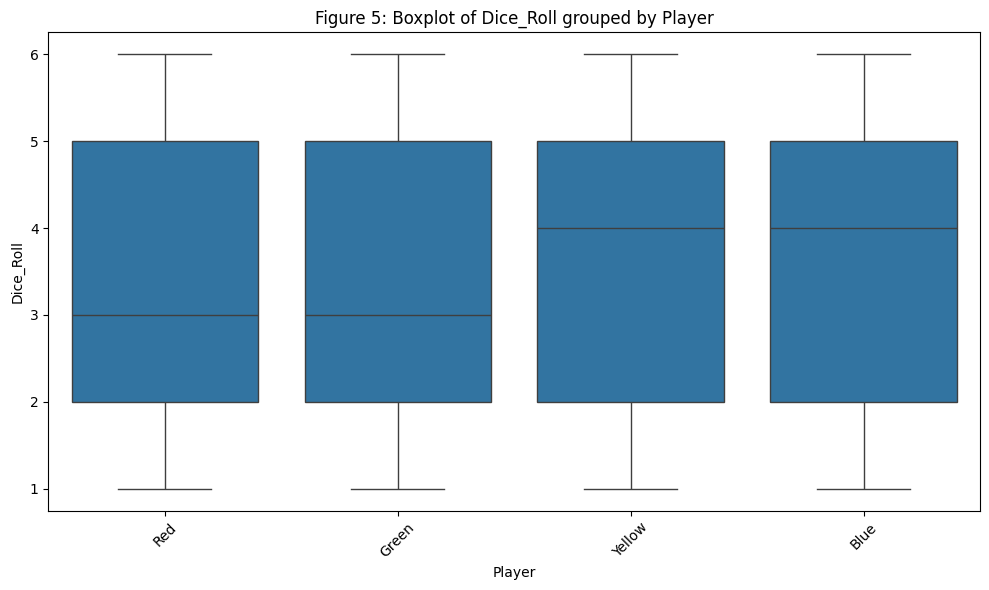

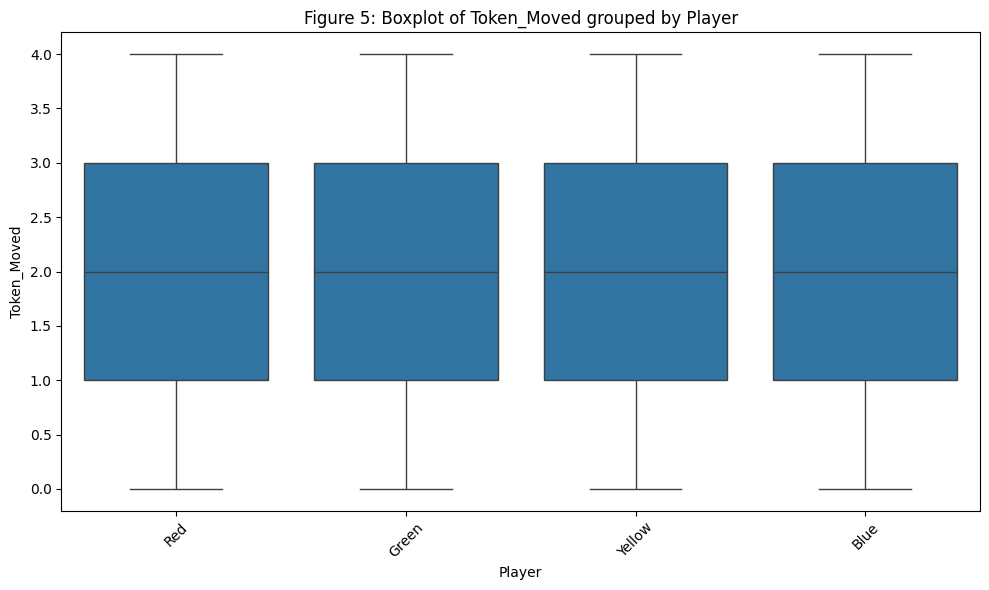

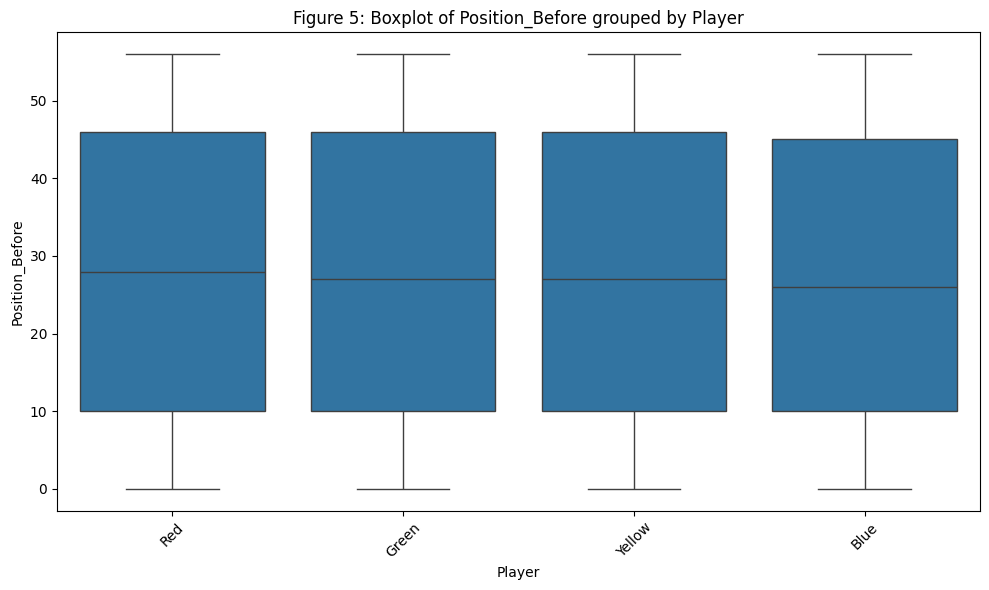

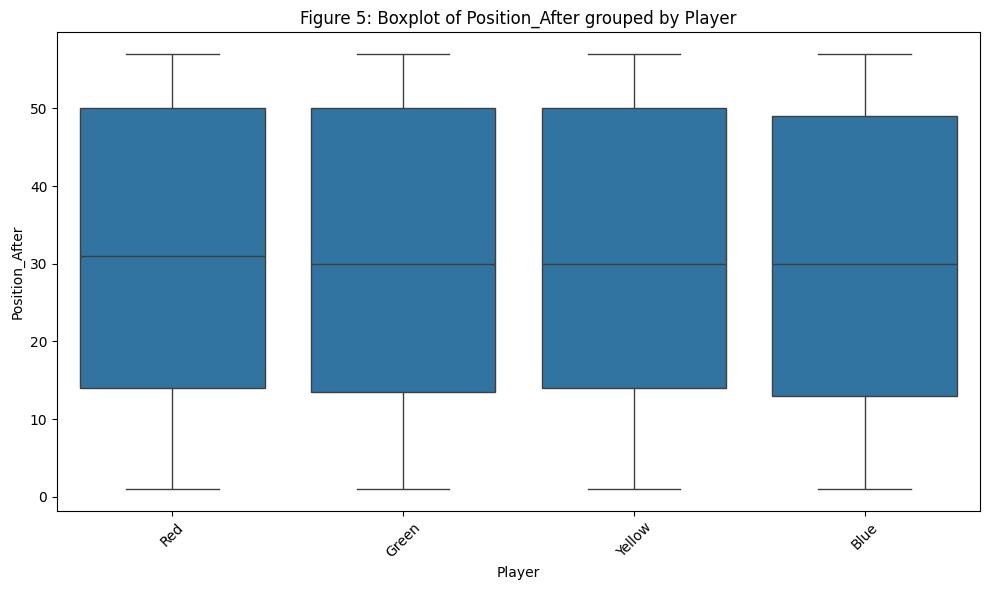

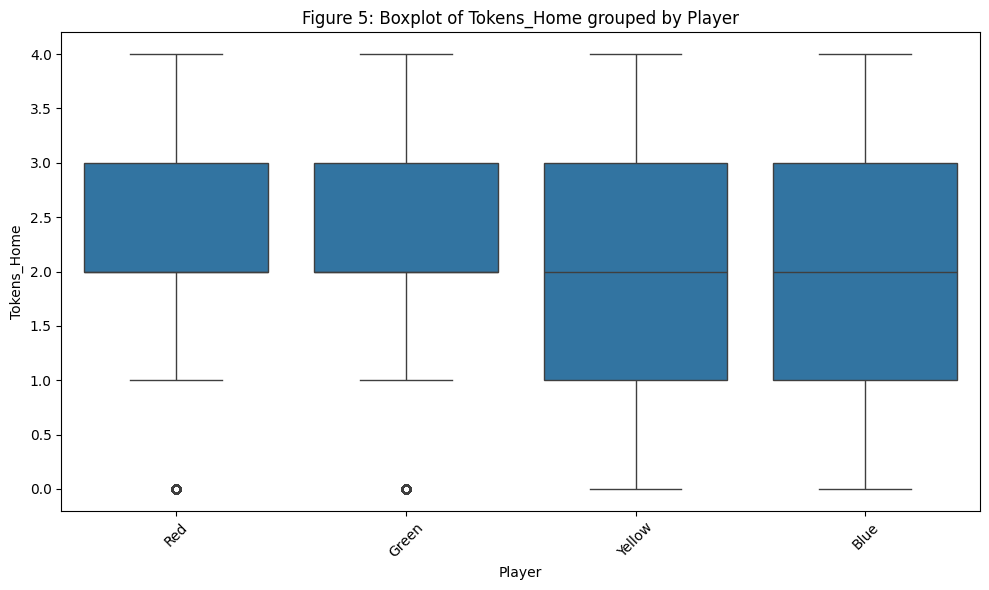

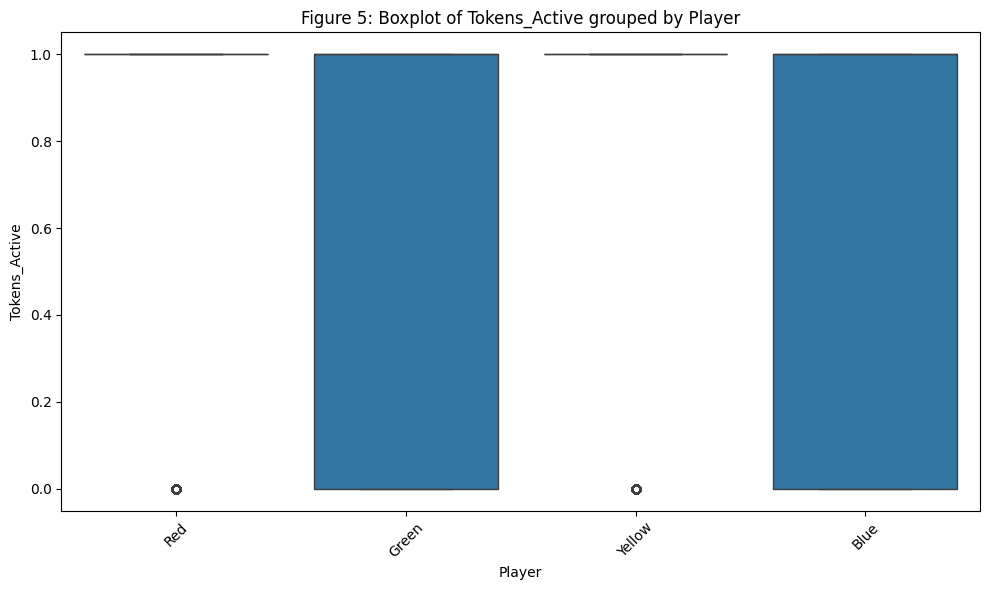

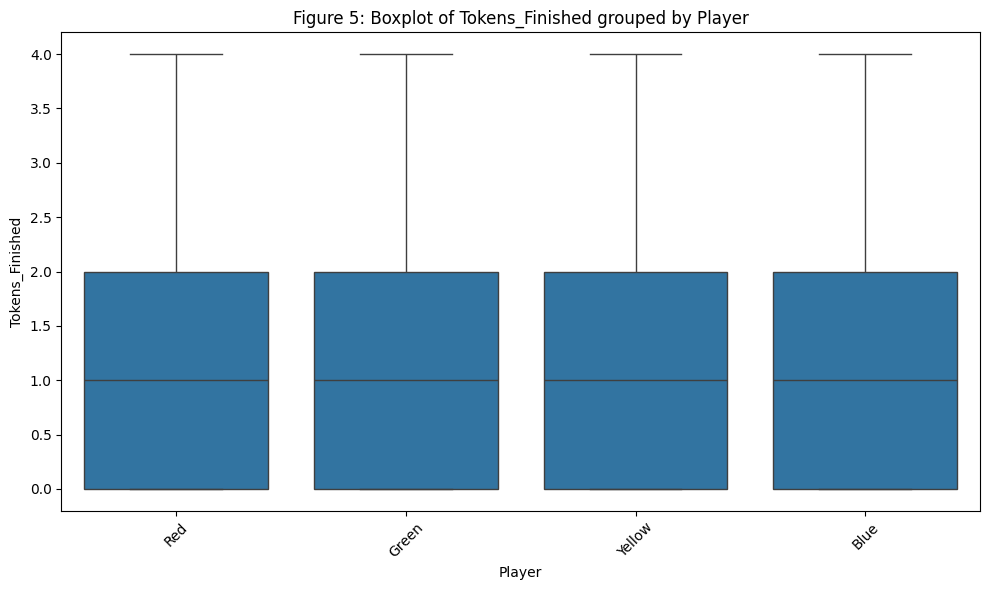

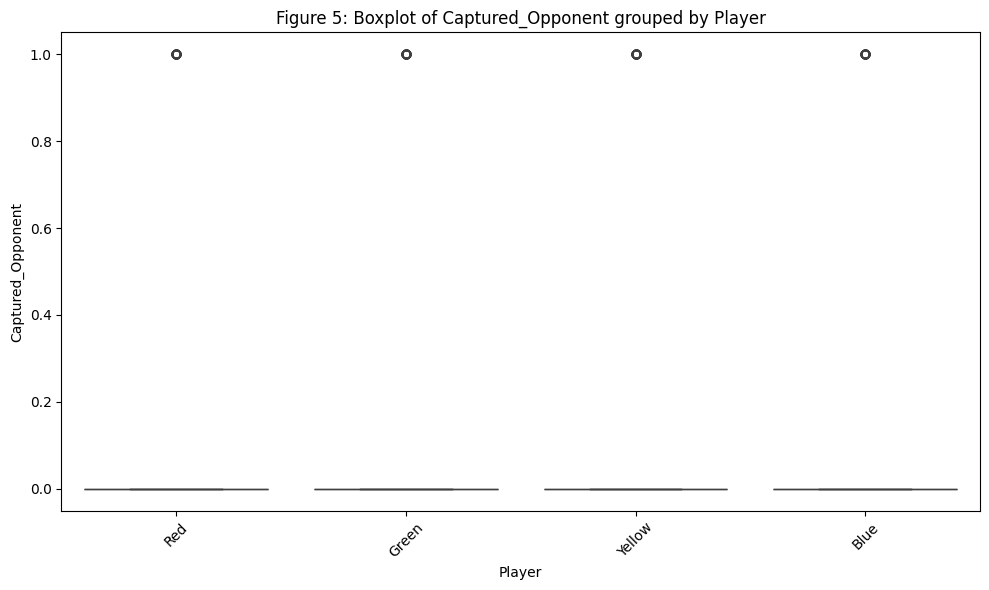

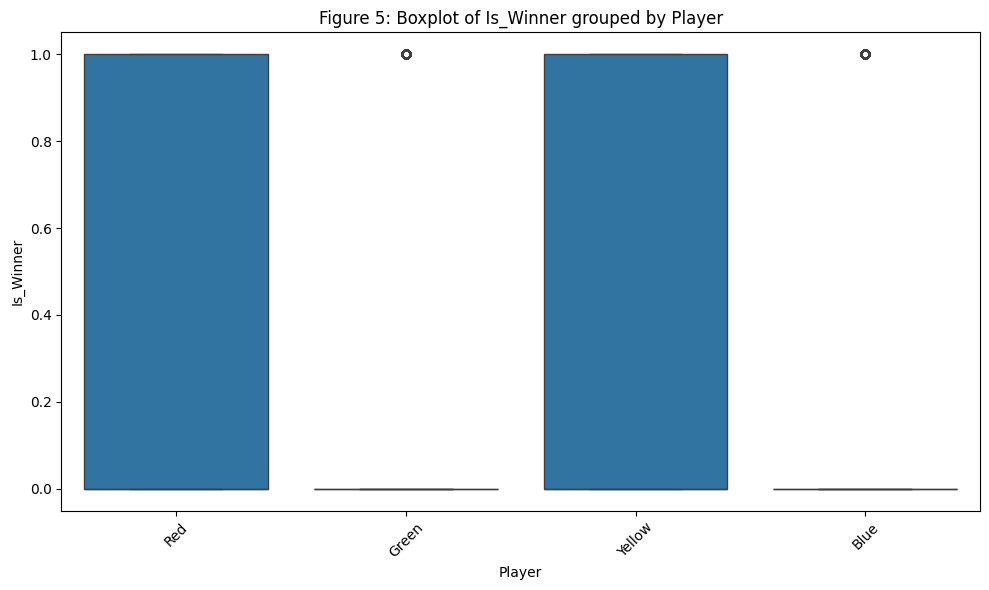

In [10]:
 # Distribution of the numeric variables when grouped by the categorical variables using boxplots
for cat_col in df_cat.columns:
    for num_col in df_num.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=df[cat_col], y=df[num_col])
        plt.title(f'Figure 5: Boxplot of {num_col} grouped by {cat_col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Statistical Tests

### Cell explanation
**Purpose:** Quantify monotonic relationships among numeric variables.

**Input:** Numeric subset `df_num`.

**Output:** Spearman correlation matrix heatmap.

**Interpretation:** Strong positive/negative values indicate stronger monotonic association.

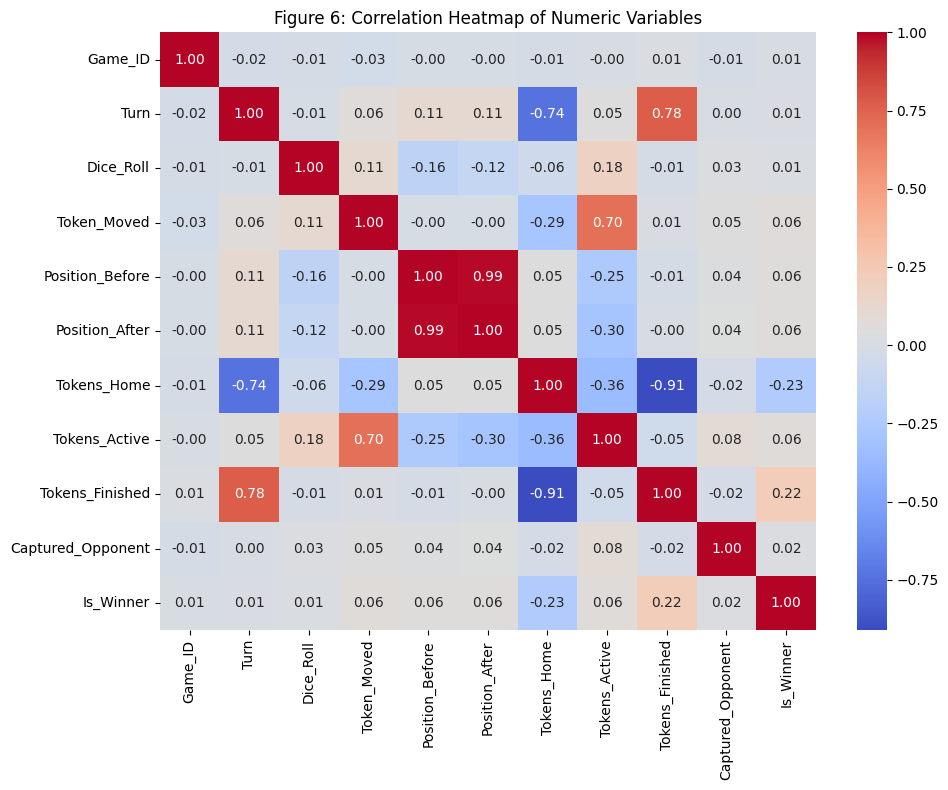

In [11]:
# Correlation heatmap of numeric variables
plt.figure(figsize=(10, 8))
correlation_matrix = df_num.corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Figure 6: Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

### Cell explanation
**Purpose:** Test normality for each numeric variable.

**Input:** Numeric columns from `df_num`.

**Null hypothesis ($H_0$):** Each numeric variable is normally distributed.

**Output:** A table with test used, statistic, $p$-value, null hypothesis statement, and accept/reject decision at $\alpha=0.05$.

**Interpretation:** Rejecting $H_0$ indicates non-normality; accepting $H_0$ indicates normality at the chosen significance level.

In [12]:
# Tests for normality of numeric variables with automatic method switch from shapiro to normaltest(n > 5000), alpha=0.05
normality_rows = []
alpha = 0.05

for col in df_num.columns:
    series = df_num[col].dropna()
    method = 'normaltest' if len(series) > 5000 else 'shapiro'
    result = pg.normality(series, method=method, alpha=alpha)

    p_value = result['pval'].iloc[0]
    is_normal = bool(result['normal'].iloc[0])
    decision = 'Accept H0' if is_normal else 'Reject H0'
    normality_rows.append({
        'variable': col,
        'n': len(series),
        'test_used': method,
        'null_hypothesis': 'Variable is normally distributed',
        'statistic': result.iloc[0, 0],
        'p_value': p_value,
        'normal': is_normal,
        'decision': decision,
        'indication': 'Normally distributed' if is_normal else 'Not normally distributed',
    })

normality_df = pd.DataFrame(normality_rows)
normality_df

,variable,n,test_used,null_hypothesis,statistic,p_value,normal,decision,indication
0,Game_ID,11104,normaltest,Variable is normally distributed,1.608647e+04,0.000000e+00,False,Reject H0,Not normally distributed
1,Turn,11104,normaltest,Variable is normally distributed,4.782521e+02,1.408913e-104,False,Reject H0,Not normally distributed
2,Dice_Roll,11104,normaltest,Variable is normally distributed,2.574217e+04,0.000000e+00,False,Reject H0,Not normally distributed
3,Token_Moved,11104,normaltest,Variable is normally distributed,2.781027e+06,0.000000e+00,False,Reject H0,Not normally distributed
4,Position_Before,8556,normaltest,Variable is normally distributed,8.695451e+04,0.000000e+00,False,Reject H0,Not normally distributed
5,Position_After,8556,normaltest,Variable is normally distributed,9.152747e+04,0.000000e+00,False,Reject H0,Not normally distributed
6,Tokens_Home,11104,normaltest,Variable is normally distributed,5.223001e+02,3.836833e-114,False,Reject H0,Not normally distributed
7,Tokens_Active,11104,normaltest,Variable is normally distributed,2.198863e+03,0.000000e+00,False,Reject H0,Not normally distributed
8,Tokens_Finished,11104,normaltest,Variable is normally distributed,1.179321e+03,8.197611e-257,False,Reject H0,Not normally distributed
9,Captured_Opponent,11104,normaltest,Variable is normally distributed,1.337192e+04,0.000000e+00,False,Reject H0,Not normally distributed


### Cell explanation
**Purpose:** Test normality within each category level for each numeric variable.

**Input:** Categorical columns, numeric columns, and grouped subsets.

**Null hypothesis ($H_0$):** For each group, the numeric variable is normally distributed.

**Output:** Group-level normality results with test used, statistic, $p$-value, null hypothesis statement, and accept/reject decision.

**Interpretation:** Helps validate distribution assumptions before grouped comparisons.

In [13]:
# Tests for normality of numeric variables within each category level, alpha=0.05
grouped_normality_rows = []
alpha = 0.05

for cat_col in df_cat.columns:
    for num_col in df_num.columns:
        subset = df[[cat_col, num_col]].dropna()
        for group_name, group_df in subset.groupby(cat_col):
            series = group_df[num_col]
            n = len(series)

            if n < 3:
                grouped_normality_rows.append({
                    'categorical_variable': cat_col,
                    'category': group_name,
                    'numeric_variable': num_col,
                    'n': n,
                    'test_used': None,
                    'null_hypothesis': 'Group variable is normally distributed',
                    'statistic': np.nan,
                    'p_value': np.nan,
                    'normal': False,
                    'decision': 'Reject H0',
                    'indication': 'Insufficient sample size (n < 3)'
                })
                continue

            method = 'normaltest' if n > 5000 else 'shapiro'
            result = pg.normality(series, method=method, alpha=alpha)

            p_value = result['pval'].iloc[0]
            is_normal = bool(result['normal'].iloc[0])
            decision = 'Accept H0' if is_normal else 'Reject H0'

            grouped_normality_rows.append({
                'categorical_variable': cat_col,
                'category': group_name,
                'numeric_variable': num_col,
                'n': n,
                'test_used': method,
                'null_hypothesis': 'Group variable is normally distributed',
                'statistic': result.iloc[0, 0],
                'p_value': p_value,
                'normal': is_normal,
                'decision': decision,
                'indication': 'Normally distributed' if is_normal else 'Not normally distributed'
            })

grouped_normality_df = pd.DataFrame(grouped_normality_rows)
grouped_normality_df

,categorical_variable,category,numeric_variable,n,test_used,null_hypothesis,statistic,p_value,normal,decision,indication
0,Player,Blue,Game_ID,2769,shapiro,Group variable is normally distributed,0.942993,1.977329e-31,False,Reject H0,Not normally distributed
1,Player,Green,Game_ID,2779,shapiro,Group variable is normally distributed,0.943801,2.705917e-31,False,Reject H0,Not normally distributed
2,Player,Red,Game_ID,2757,shapiro,Group variable is normally distributed,0.945084,6.946862e-31,False,Reject H0,Not normally distributed
3,Player,Yellow,Game_ID,2799,shapiro,Group variable is normally distributed,0.943772,2.120738e-31,False,Reject H0,Not normally distributed
4,Player,Blue,Turn,2769,shapiro,Group variable is normally distributed,0.973270,2.353142e-22,False,Reject H0,Not normally distributed
5,Player,Green,Turn,2779,shapiro,Group variable is normally distributed,0.971637,4.773249e-23,False,Reject H0,Not normally distributed
6,Player,Red,Turn,2757,shapiro,Group variable is normally distributed,0.972785,1.676532e-22,False,Reject H0,Not normally distributed
7,Player,Yellow,Turn,2799,shapiro,Group variable is normally distributed,0.971326,2.984090e-23,False,Reject H0,Not normally distributed
8,Player,Blue,Dice_Roll,2769,shapiro,Group variable is normally distributed,0.904383,1.438212e-38,False,Reject H0,Not normally distributed
9,Player,Green,Dice_Roll,2779,shapiro,Group variable is normally distributed,0.903713,9.990663e-39,False,Reject H0,Not normally distributed


Since most variables/groups are non-normally distributed, non-parametric tests are appropriate. The next cells apply Kruskal-Wallis and Mann-Whitney U tests and add concentration overlays to significant plots.

**How to read the new concentration parameters**
- **IQR band ($Q1$ to $Q3$):** middle 50% of values; narrower bands indicate tighter concentration.
- **Median ($Q2$):** central location; compare medians to see which group tends to have higher/lower typical values.
- **Peak (approximate mode):** highest-density/most frequent region; indicates where values cluster most strongly.

These overlays complement $p$-values by showing practical distribution shape and location differences.

### Cell explanation
**Purpose:** Compare numeric variables across player groups using Kruskal-Wallis tests.

**Input:** Grouping variable `Player` and numeric variables.

**Null hypothesis ($H_0$):** The distributions (medians) of the numeric variable are equal across player groups.

**Output:** A displayed results table (test statistics, $p$-values, accept/reject decisions), swarmplot + boxplot visualizations for statistically significant variables only at $\alpha=0.05$, and a per-player concentration summary table (`Q1`, `Median`, `Q3`, `Peak_Approx`).

**Interpretation guide for new parameters:**
- **`Q1` and `Q3` (IQR):** show each player's middle 50% range.
- **`Median`:** typical value for each player.
- **`Peak_Approx`:** approximate highest concentration point (mode region).

Use these parameters together to explain not just *whether* groups differ, but *how* they differ in location and concentration.

,grouping_variable,numeric_variable,groups_compared,null_hypothesis,alpha,statistic,p_value,significant,decision
0,Player,Turn,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,0.489066,9.212870e-01,False,Accept H0
1,Player,Dice_Roll,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,5.847954,1.192465e-01,False,Accept H0
2,Player,Token_Moved,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,44.153432,1.400065e-09,True,Reject H0
3,Player,Position_Before,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,1.829951,6.084390e-01,False,Accept H0
4,Player,Position_After,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,1.337719,7.201965e-01,False,Accept H0
5,Player,Tokens_Home,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,34.951153,1.247544e-07,True,Reject H0
6,Player,Tokens_Active,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,2.289427,5.145495e-01,False,Accept H0
7,Player,Tokens_Finished,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,39.570947,1.313689e-08,True,Reject H0
8,Player,Captured_Opponent,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,0.653819,8.840086e-01,False,Accept H0
9,Player,Is_Winner,Blue vs Green vs Red vs Yellow,All player-group distributions are equal,0.05,499.091672,7.507897e-108,True,Reject H0


/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 33.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 28.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 40.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ch

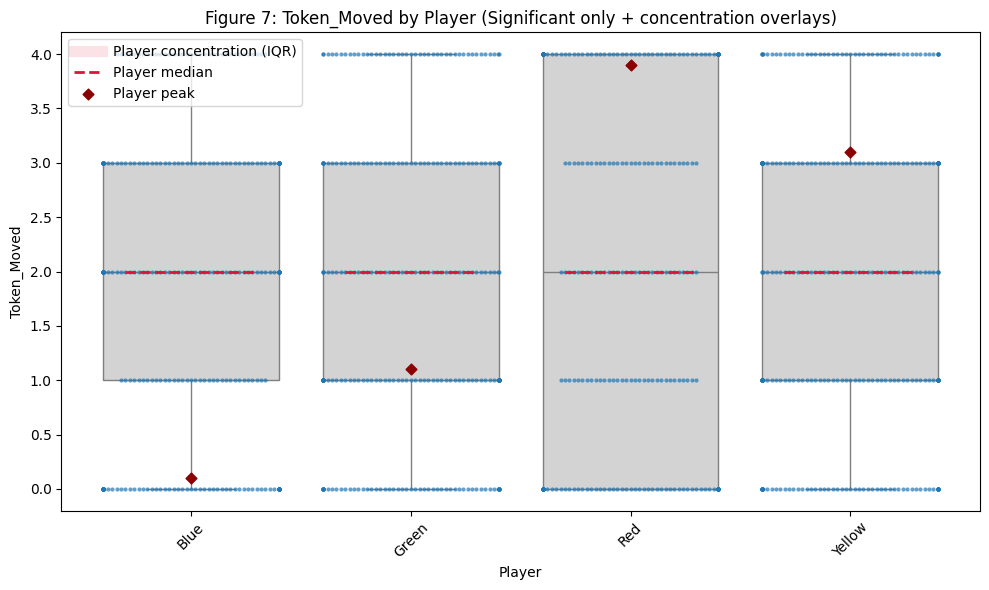

,Numeric_Variable,Player,Q1,Median,Q3,Peak_Approx
0,Token_Moved,Blue,1.0,2.0,3.0,0.1
1,Token_Moved,Green,1.0,2.0,3.0,1.1
2,Token_Moved,Red,0.0,2.0,4.0,3.9
3,Token_Moved,Yellow,1.0,2.0,3.0,3.1


/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 46.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 46.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 39.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 48.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ch

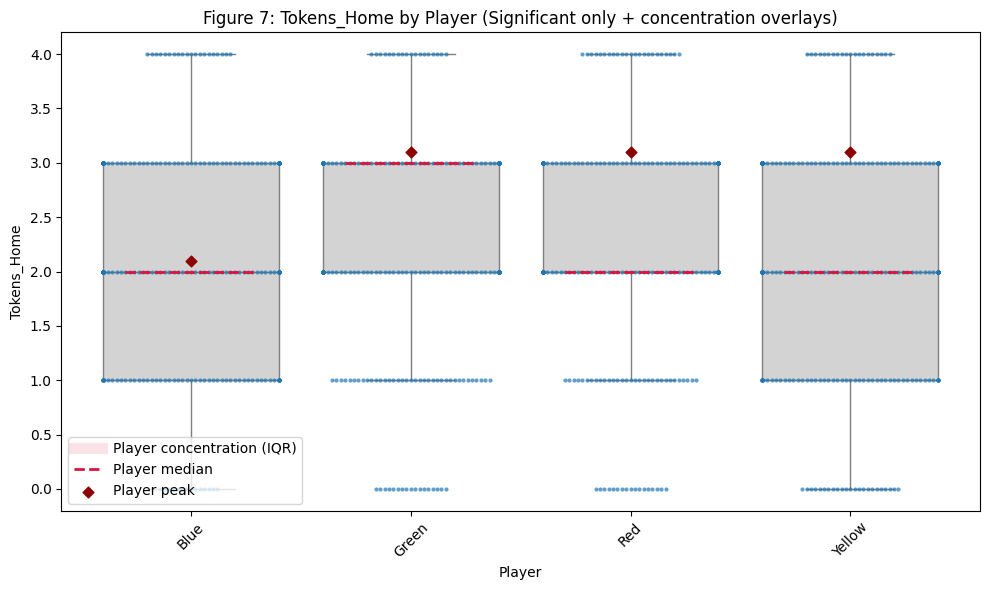

,Numeric_Variable,Player,Q1,Median,Q3,Peak_Approx
0,Tokens_Home,Blue,1.0,2.0,3.0,2.1
1,Tokens_Home,Green,2.0,3.0,3.0,3.1
2,Tokens_Home,Red,2.0,2.0,3.0,3.1
3,Tokens_Home,Yellow,1.0,2.0,3.0,3.1


/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 51.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 51.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 46.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 54.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ch

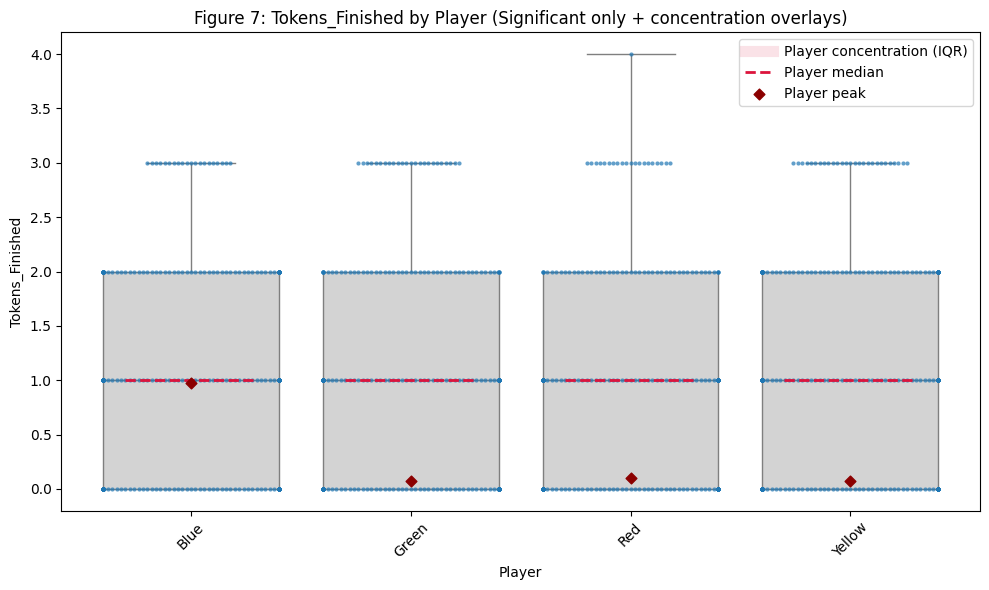

,Numeric_Variable,Player,Q1,Median,Q3,Peak_Approx
0,Tokens_Finished,Blue,0.0,1.0,2.0,0.98
1,Tokens_Finished,Green,0.0,1.0,2.0,0.08
2,Tokens_Finished,Red,0.0,1.0,2.0,0.10
3,Tokens_Finished,Yellow,0.0,1.0,2.0,0.08


/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 73.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 73.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 70.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/chizoalban2003/ludomaniac/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 76.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ch

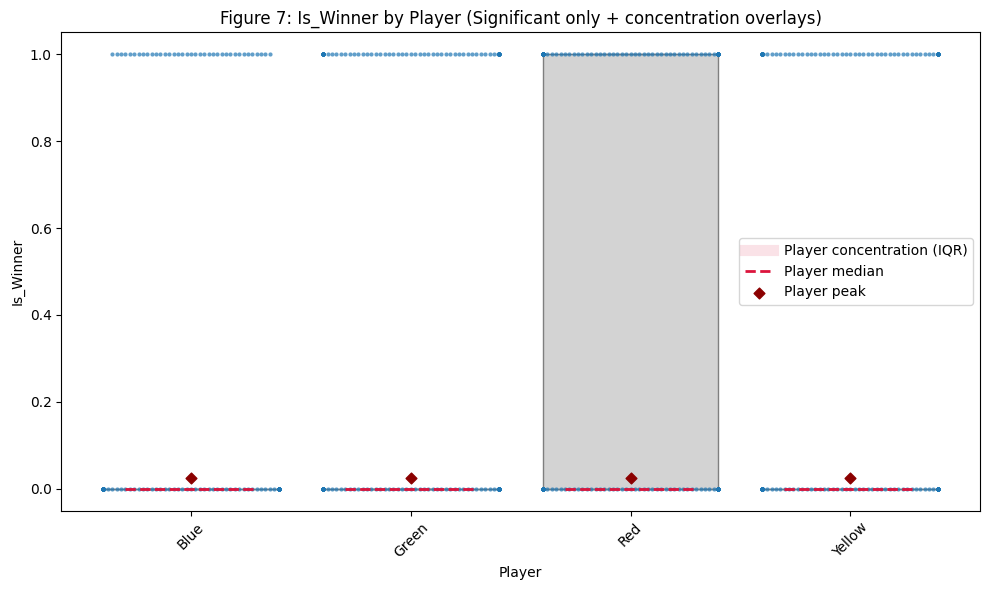

,Numeric_Variable,Player,Q1,Median,Q3,Peak_Approx
0,Is_Winner,Blue,0.0,0.0,0.0,0.02
1,Is_Winner,Green,0.0,0.0,0.0,0.02
2,Is_Winner,Red,0.0,0.0,1.0,0.02
3,Is_Winner,Yellow,0.0,0.0,0.0,0.02


In [14]:
# Kruskal-Wallis tests for numeric variables across Player groups, alpha=0.05
alpha = 0.05
kruskal_rows = []

group_col = 'Player'
for num_col in df_num.columns:
    if num_col == 'Game_ID':
        continue

    subset = df[[group_col, num_col]].dropna()
    unique_groups = sorted(subset[group_col].unique())
    groups_compared = ' vs '.join(map(str, unique_groups))
    groups = [group[num_col].values for _, group in subset.groupby(group_col)]

    if len(groups) < 2 or any(len(group) == 0 for group in groups):
        kruskal_rows.append({
            'grouping_variable': group_col,
            'numeric_variable': num_col,
            'groups_compared': groups_compared,
            'null_hypothesis': 'All player-group distributions are equal',
            'alpha': alpha,
            'statistic': np.nan,
            'p_value': np.nan,
            'significant': False,
            'decision': 'Accept H0'
        })
        continue

    result = pg.kruskal(data=subset, dv=num_col, between=group_col)
    p_value = result['p_unc'].iloc[0]
    significant = bool(p_value < alpha)

    kruskal_rows.append({
        'grouping_variable': group_col,
        'numeric_variable': num_col,
        'groups_compared': groups_compared,
        'null_hypothesis': 'All player-group distributions are equal',
        'alpha': alpha,
        'statistic': result['H'].iloc[0],
        'p_value': p_value,
        'significant': significant,
        'decision': 'Reject H0' if significant else 'Accept H0'
    })

kruskal_df = pd.DataFrame(kruskal_rows)

# Always show the test result table when this cell runs
display(kruskal_df)

# Visualizations: boxplot + swarmplot only for variables with statistically significant differences
significant_vars = kruskal_df.loc[kruskal_df['significant'], 'numeric_variable'].tolist()

if not significant_vars:
    print('No statistically significant variables found at alpha=0.05; no swarmplots generated.')
else:
    for num_col in significant_vars:
        plot_df = df[[group_col, num_col]].dropna()
        if plot_df.empty:
            continue

        # Downsample for readability and speed on large datasets
        if len(plot_df) > 1000:
            plot_df = plot_df.sample(n=1000, random_state=42)

        player_order = sorted(plot_df[group_col].unique())

        plt.figure(figsize=(10, 6))
        sns.boxplot(
            data=plot_df,
            x=group_col,
            y=num_col,
            order=player_order,
            color='lightgray',
            showfliers=False
        )
        sns.swarmplot(
            data=plot_df,
            x=group_col,
            y=num_col,
            order=player_order,
            size=3,
            alpha=0.7
        )

        # Emphasize concentration region per player group (IQR, median, and peak)
        concentration_rows = []
        ax = plt.gca()
        for i, player in enumerate(player_order):
            player_vals = plot_df.loc[plot_df[group_col] == player, num_col]
            if len(player_vals) <= 1:
                continue

            q1, q2, q3 = player_vals.quantile([0.25, 0.50, 0.75])
            hist_counts, bin_edges = np.histogram(player_vals, bins=20, density=True)
            peak_idx = int(np.argmax(hist_counts))
            peak_y = (bin_edges[peak_idx] + bin_edges[peak_idx + 1]) / 2

            # IQR band around each player category
            ax.fill_between([i - 0.35, i + 0.35], q1, q3, color='crimson', alpha=0.08, zorder=0)
            # Median indicator
            ax.hlines(q2, i - 0.30, i + 0.30, colors='crimson', linestyles='--', linewidth=2, zorder=4)
            # Peak marker (approximate mode region)
            ax.scatter(i, peak_y, color='darkred', marker='D', s=30, zorder=5)

            concentration_rows.append({
                'Player': player,
                'Q1': float(q1),
                'Median': float(q2),
                'Q3': float(q3),
                'Peak_Approx': float(peak_y)
            })

        # Compact legend for concentration overlays
        plt.plot([], [], color='crimson', linewidth=8, alpha=0.12, label='Player concentration (IQR)')
        plt.plot([], [], color='crimson', linestyle='--', linewidth=2, label='Player median')
        plt.scatter([], [], color='darkred', marker='D', s=30, label='Player peak')

        plt.title(f'Figure 7: {num_col} by {group_col} (Significant only + concentration overlays)')
        plt.xticks(rotation=45)
        plt.ylabel(num_col)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

        # Display player concentration summary for the current significant variable
        if concentration_rows:
            concentration_df = pd.DataFrame(concentration_rows)
            concentration_df.insert(0, 'Numeric_Variable', num_col)
            display(concentration_df.round(2))

### Cell explanation
**Purpose:** Compare winner vs non-winner groups using Mann-Whitney U tests.

**Input:** Grouping variable `Is_Winner` and numeric variables.

**Null hypothesis ($H_0$):** The two winner-status groups come from the same distribution for the numeric variable.

**Output:** A displayed results table (U statistics, $p$-values, accept/reject decisions) and histplot + KDE visualizations for statistically significant variables only at $\alpha=0.05$, including winner concentration overlays.

**Interpretation guide for new parameters (for `Is_Winner = 1`):**
- **IQR band ($Q1$ to $Q3$):** where the middle 50% of winner values lie.
- **Median line:** typical winner value.
- **Peak marker:** most concentrated winner region (approximate mode).

These overlays clarify where winner outcomes are concentrated and how far they separate from non-winner distributions.

,grouping_variable,numeric_variable,groups_compared,null_hypothesis,alpha,u_value,p_value,significant,decision
0,Is_Winner,Turn,0 vs 1,Both winner-status groups have equal distribut...,0.05,11662408.5,3.436587e-01,False,Accept H0
1,Is_Winner,Dice_Roll,0 vs 1,Both winner-status groups have equal distribut...,0.05,11581509.0,1.296232e-01,False,Accept H0
2,Is_Winner,Token_Moved,0 vs 1,Both winner-status groups have equal distribut...,0.05,10872140.5,1.309582e-10,True,Reject H0
3,Is_Winner,Position_Before,0 vs 1,Both winner-status groups have equal distribut...,0.05,6805749.0,2.839426e-07,True,Reject H0
4,Is_Winner,Position_After,0 vs 1,Both winner-status groups have equal distribut...,0.05,6776655.0,6.022537e-08,True,Reject H0
5,Is_Winner,Tokens_Home,0 vs 1,Both winner-status groups have equal distribut...,0.05,15298936.0,8.448305e-135,True,Reject H0
6,Is_Winner,Tokens_Active,0 vs 1,Both winner-status groups have equal distribut...,0.05,11102690.5,3.245883e-10,True,Reject H0
7,Is_Winner,Tokens_Finished,0 vs 1,Both winner-status groups have equal distribut...,0.05,8518392.0,1.033559e-120,True,Reject H0
8,Is_Winner,Captured_Opponent,0 vs 1,Both winner-status groups have equal distribut...,0.05,11715264.5,1.596819e-02,True,Reject H0


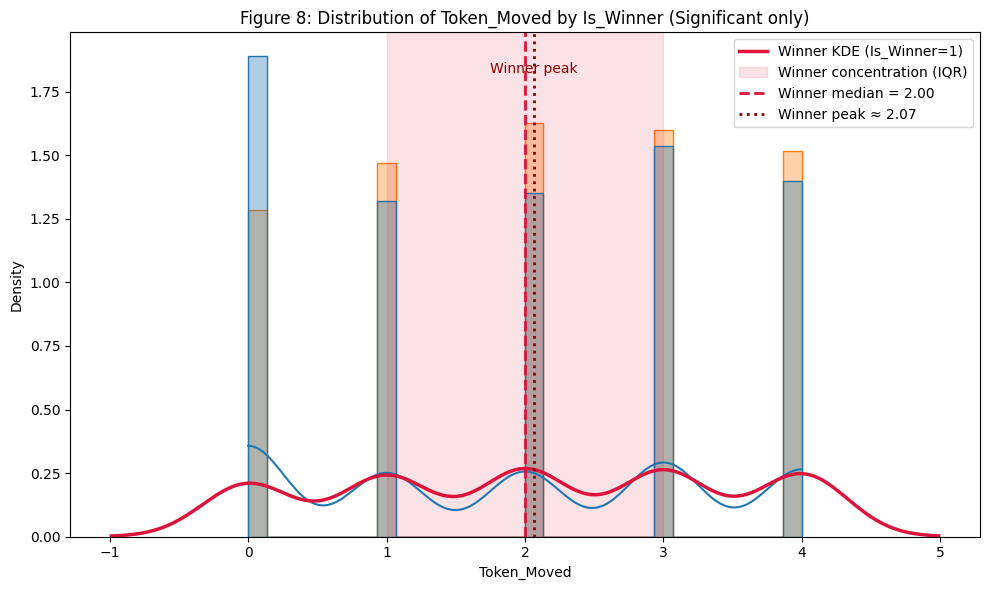

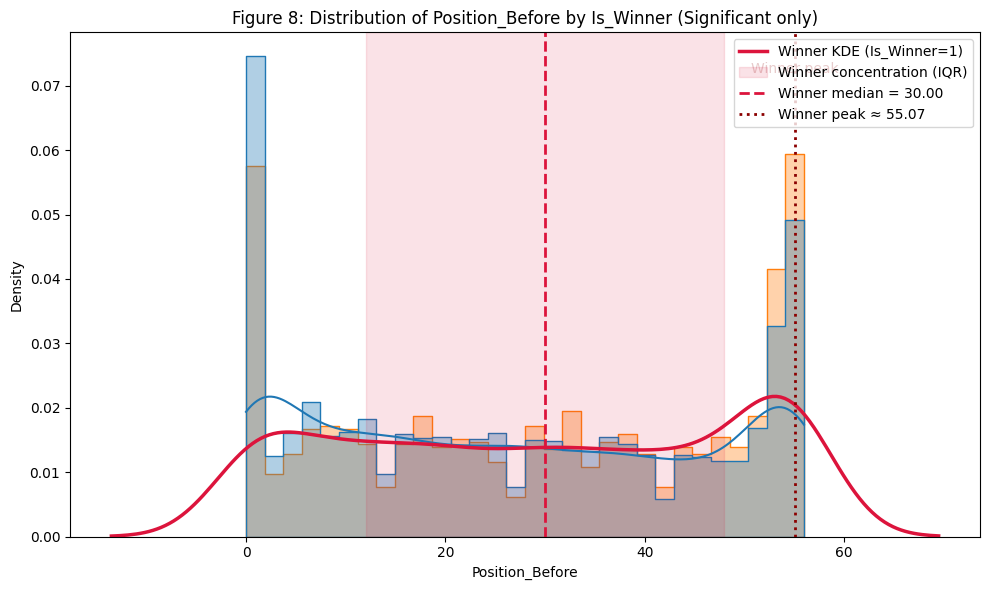

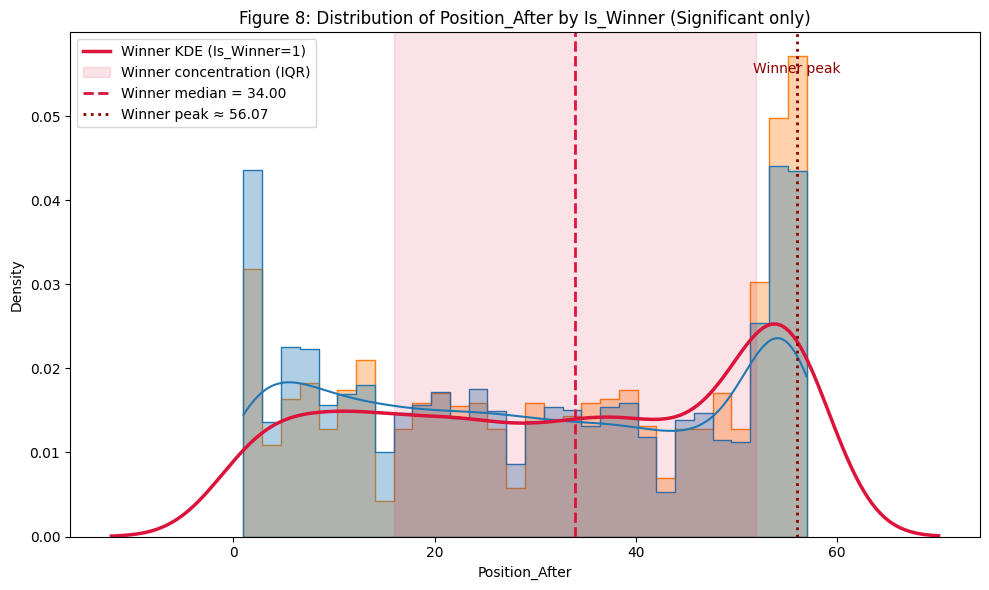

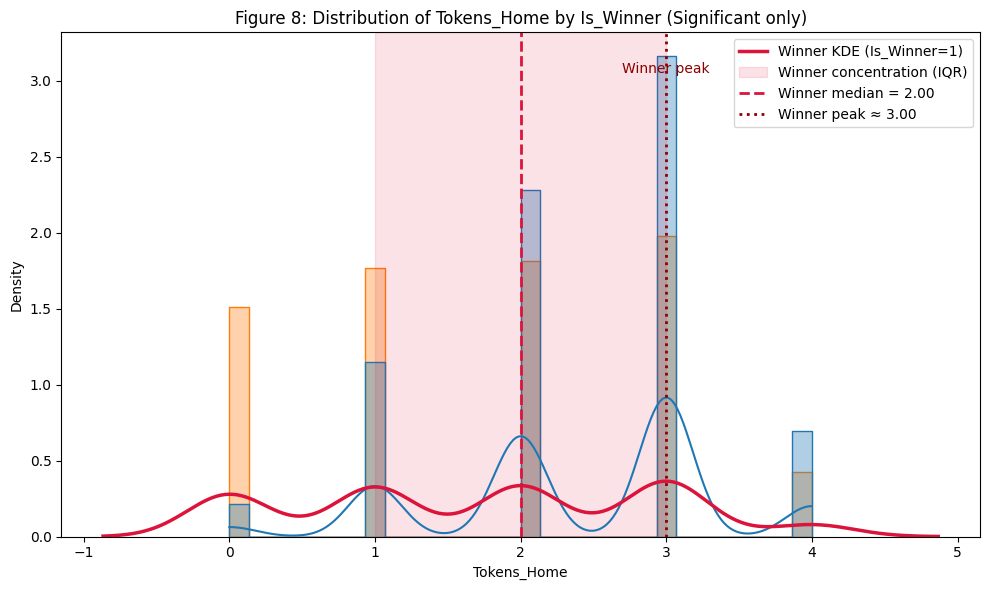

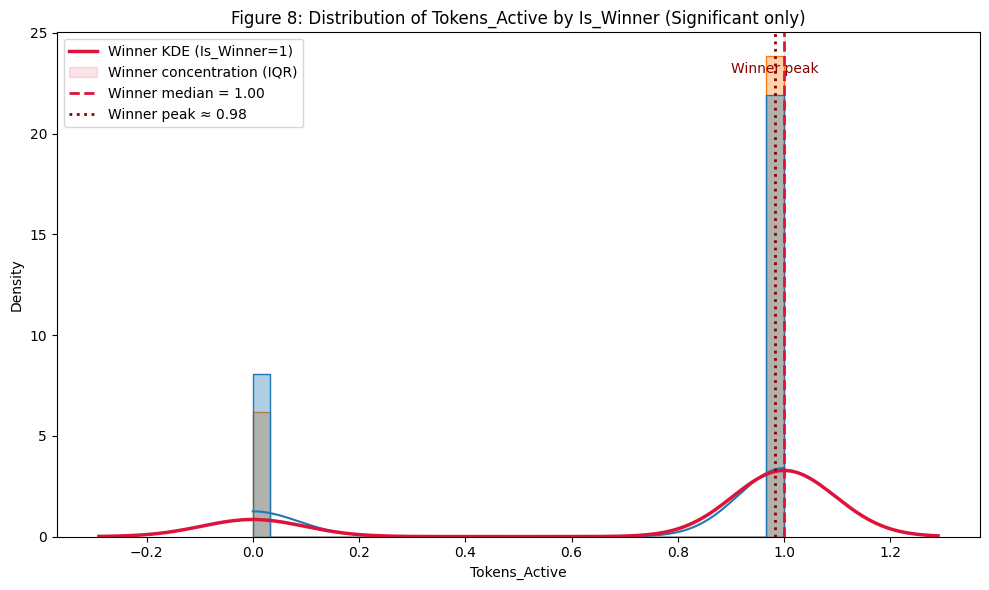

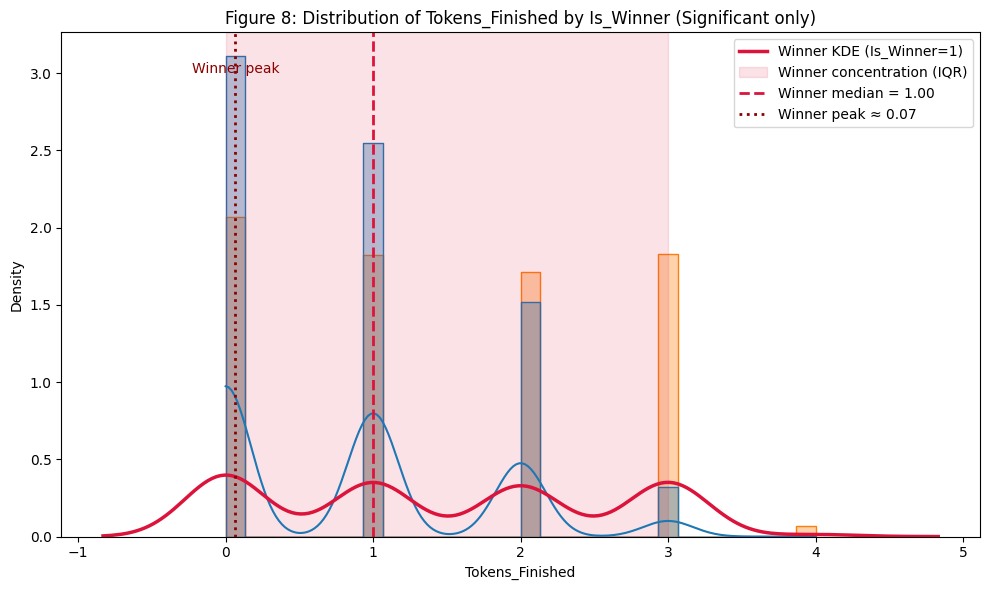

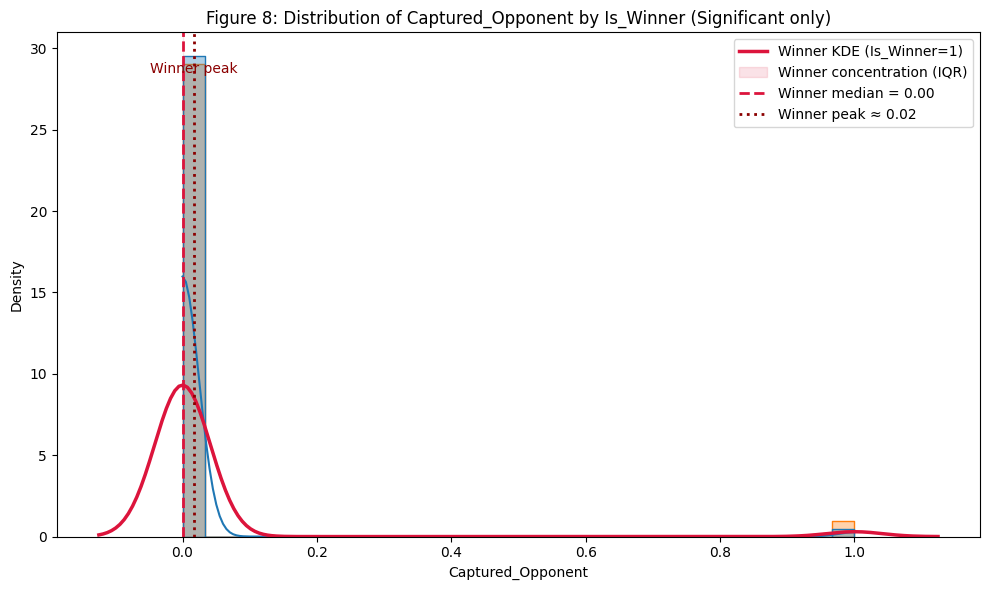

In [15]:
# Mann-Whitney U tests for numeric variables by winner status, alpha=0.05
alpha = 0.05
mwu_rows = []

group_col = 'Is_Winner'
for num_col in df_num.columns:
    if num_col in ['Game_ID', group_col]:
        continue

    subset = df[[group_col, num_col]].dropna()
    unique_groups = sorted(subset[group_col].unique())

    if len(unique_groups) != 2:
        mwu_rows.append({
            'grouping_variable': group_col,
            'numeric_variable': num_col,
            'null_hypothesis': 'Both winner-status groups have equal distributions',
            'alpha': alpha,
            'u_value': np.nan,
            'p_value': np.nan,
            'significant': False,
            'decision': 'Accept H0'
        })
        continue

    x = subset.loc[subset[group_col] == unique_groups[0], num_col]
    y = subset.loc[subset[group_col] == unique_groups[1], num_col]

    if len(x) == 0 or len(y) == 0:
        mwu_rows.append({
            'grouping_variable': group_col,
            'numeric_variable': num_col,
            'null_hypothesis': 'Both winner-status groups have equal distributions',
            'alpha': alpha,
            'u_value': np.nan,
            'p_value': np.nan,
            'significant': False,
            'decision': 'Accept H0'
        })
        continue

    result = pg.mwu(x, y, alternative='two-sided')
    p_value = result['p_val'].iloc[0]
    significant = bool(p_value < alpha)

    mwu_rows.append({
        'grouping_variable': group_col,
        'numeric_variable': num_col,
        'groups_compared': f'{unique_groups[0]} vs {unique_groups[1]}',
        'null_hypothesis': 'Both winner-status groups have equal distributions',
        'alpha': alpha,
        'u_value': result['U_val'].iloc[0],
        'p_value': p_value,
        'significant': significant,
        'decision': 'Reject H0' if significant else 'Accept H0'
    })

mwu_df = pd.DataFrame(mwu_rows)

# Always show the test result table when this cell runs
display(mwu_df)

# Visualizations: histplot + KDE only for variables with statistically significant differences
significant_vars_mwu = mwu_df.loc[mwu_df['significant'], 'numeric_variable'].tolist()

if not significant_vars_mwu:
    print('No statistically significant variables found at alpha=0.05; no histplot/KDE generated.')
else:
    for num_col in significant_vars_mwu:
        plot_df = df[[group_col, num_col]].dropna()
        if plot_df.empty:
            continue

        # Downsample for readability and speed on large datasets
        if len(plot_df) > 5000:
            plot_df = plot_df.sample(n=5000, random_state=42)

        plt.figure(figsize=(10, 6))
        sns.histplot(
            data=plot_df,
            x=num_col,
            hue=group_col,
            kde=True,
            stat='density',
            common_norm=False,
            bins=30,
            alpha=0.35,
            element='step'
        )

        # Emphasize concentration region for winners (Is_Winner == 1)
        winner_vals = plot_df.loc[plot_df[group_col] == 1, num_col]
        if len(winner_vals) > 1:
            q1, q2, q3 = winner_vals.quantile([0.25, 0.50, 0.75])
            hist_counts, bin_edges = np.histogram(winner_vals, bins=30, density=True)
            peak_idx = int(np.argmax(hist_counts))
            peak_x = (bin_edges[peak_idx] + bin_edges[peak_idx + 1]) / 2

            # Winner-focused KDE and concentration markers
            sns.kdeplot(winner_vals, color='crimson', linewidth=2.5, label='Winner KDE (Is_Winner=1)')
            plt.axvspan(q1, q3, color='crimson', alpha=0.12, label='Winner concentration (IQR)')
            plt.axvline(q2, color='crimson', linestyle='--', linewidth=2, label=f'Winner median = {q2:.2f}')
            plt.axvline(peak_x, color='darkred', linestyle=':', linewidth=2, label=f'Winner peak ≈ {peak_x:.2f}')

            ymax = plt.ylim()[1]
            plt.text(peak_x, ymax * 0.92, 'Winner peak', color='darkred', ha='center')

        plt.title(f'Figure 8: Distribution of {num_col} by {group_col} (Significant only)')
        plt.xlabel(num_col)
        plt.ylabel('Density')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

# Conclusion
- The dataset was successfully loaded, checked for quality issues, and exported in cleaned form.
- The simulation now reflects **real Ludo rules**: each of the 4 players controls **4 tokens**, with proper home-yard entry (requires a 6), bounce-back on overshoot, opponent captures (sending tokens back to home), and extra turns on rolling a 6 or capturing.
- The richer feature set — `Token_Moved`, `Position_Before`, `Position_After`, `Tokens_Home`, `Tokens_Active`, `Tokens_Finished`, `Captured_Opponent` — provides far more signal for a predictive model than the previous single-token simplification.
- Exploratory plots revealed key distribution patterns, potential outliers, and group differences across all 12 columns; subplot grids now scale dynamically to the number of variables.
- Normality checks confirmed that most variables and groups do not satisfy normality assumptions, making non-parametric tests appropriate.
- Kruskal-Wallis tests compared numeric variables across player groups; significant variables are visualised with swarmplots and per-player concentration overlays (`Q1`, `Median`, `Q3`, `Peak_Approx`).
- Mann-Whitney U tests compared winner vs. non-winner distributions; significant variables are visualised with KDE histplots and winner-focused concentration overlays.

**Interpretation of concentration parameters:**
- **IQR ($Q1$–$Q3$):** spread and concentration of the middle 50% of observations.
- **Median ($Q2$):** robust central tendency for group comparison.
- **Peak (approximate mode):** highest-density location, useful for identifying dominant outcome regions.

Overall, the analysis now reflects authentic 4-token Ludo dynamics and provides both statistical significance and distribution-shape interpretation, strengthening decisions for feature engineering and model training.
